In [1]:
import scvi
import scanpy as sc
import anndata as ad
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
 

/software/cellgen/team298/ls34/scpoli/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
sc.logging.print_versions()




-----
anndata     0.10.7
scanpy      1.10.1
-----
PIL                 10.3.0
absl                NA
asttokens           NA
attr                23.2.0
chex                0.1.86
comm                0.2.2
contextlib2         NA
cycler              0.12.1
cython_runtime      NA
dateutil            2.9.0.post0
debugpy             1.8.1
decorator           5.1.1
docrep              0.3.2
etils               1.9.1
executing           2.0.1
filelock            3.14.0
flax                0.8.4
fsspec              2024.6.0
h5py                3.11.0
igraph              0.11.8
ipykernel           6.29.4
jax                 0.4.35
jax_cuda12_plugin   NA
jax_plugins         NA
jaxlib              0.4.34
jedi                0.19.1
joblib              1.4.2
kiwisolver          1.4.5
legacy_api_wrap     NA
leidenalg           0.10.2
lightning           2.1.4
lightning_utilities 0.11.2
llvmlite            0.43.0
matplotlib          3.9.0
ml_collections      NA
ml_dtypes           0.4.0
mpl_toolkits   

### Max usage here 170gb. 
### Assumes GPU available for scanVI (but could do pre-processing (highest mem requirement}), then use smaller resources with GPU for integration)

# Load reference map (~60gb)

In [3]:
"""
Here we assume scRNA-seq data is being used. With Xenium data, higher-resolution annotations seemed to be achieved by mapping to scRNA-seq data also.

# dataset is available here (choose scRNA_seq)
https://cellatlas.io/studies/spatial-skin-atlas

"""

'\nHere we assume scRNA-seq data is being used. With Xenium data, higher-resolution annotations seemed to be achieved by mapping to scRNA-seq data also.\n\n# dataset is available here (choose scRNA_seq)\nhttps://cellatlas.io/studies/spatial-skin-atlas\n\n'

In [4]:
"""
PUT THE PATH TO THE REFERENCE ADATA HERE, AND THEN LOAD
"""
adata_reference_path = '/nfs/team298/ls34/adult_skin/final_adatas/adata_combined_new.h5ad.final.filtered.scrna.clean'
adata=sc.read_h5ad(adata_reference_path)
adata

AnnData object with n_obs × n_vars = 1730938 × 32732
    obs: 'sample_id', 'barcode', 'GSE', 'Site_status', 'Patient_status', 'Location', 'Age', 'Sex', 'dataset_id', 'lvl5_annotation', 'atlas_status', 'atlas_status_reynolds', 'Timepoint', 'info_id6', 'tech', 'scanvi_predictions2', 'lvl1_new', 'Site_status_binary2'
    uns: 'lvl5_annotation_colors'
    obsm: 'X_scvi', 'X_umap'

# Prepare your data

In [5]:
"""
### add path to your adata here. 

"""
#adata_tomap_path = '/lustre/scratch126/cellgen/haniffa/ls34/tmp/adata_skin_prepublication_r.h5ad'
adata_tomap_path = '/lustre/scratch124/cellgen/haniffa/projects/beacon/nobackup_data/model_scanvi5_atlasv2_nojunk_5861/adata_aa_validation.h5ad'

adata_tomap=sc.read_h5ad(adata_tomap_path)
adata_tomap.shape

(22567, 36610)

In [6]:
"""
check counts data
"""
try:
    print(adata_tomap.X[:10,:10].A)
except:
    print(adata_tomap.X[:10,:10].todense())
print("check this is counts data")

[[ 1.  0.  0.  0.  0.  0.  0.  0.  0.  0.]
 [ 0.  0.  0.  9.  0.  0.  0.  0.  0.  5.]
 [ 2.  0.  0.  0.  0.  0.  0.  0.  0.  0.]
 [ 0.  0.  0.  6.  0.  0.  0.  0.  0.  4.]
 [ 1.  0.  0.  0.  0.  0.  0.  0.  0.  3.]
 [ 0.  0.  0.  0.  0.  0.  0.  0.  0.  2.]
 [ 5.  0.  0.  0.  0.  0.  0.  0.  0.  0.]
 [ 0.  1.  0. 10.  0.  0.  0.  0.  0.  4.]
 [ 6.  0.  0.  0.  0.  0.  0.  0.  0.  0.]
 [ 0.  0.  0.  0.  0.  0.  0.  0.  0.  0.]]
check this is counts data


In [7]:
"""
We assume data to map is unlabelled
"""
adata_tomap.obs["lvl5_annotation"] = "New/unlabelled/excluded"

In [8]:
"""
SET SAMPLE ID COLUMN FROM YOUR DATA
"""
adata_tomap.obs["sample_id"] = adata_tomap.obs["orig.ident"]
#adata_tomap.obs["sample_id"].value_counts()


In [9]:
assert "sample_id" in adata_tomap.obs.columns, "ERROR: adata.obs does not contain 'sample_id'"
# adata.obs["sample_id"] = adata.obs[PUT NAME OF SAMPLE ID COLUMN HERE]


In [10]:
"""
SET PATH TO SAVE OUTPUT AND NAME OF DATASET
"""
# base dir where model output saves + preintegration adata saves
BASE = '/lustre/scratch124/cellgen/haniffa/projects/adult_skin_v1/nobackup_output/'
DATASET="AA_VALID"
adata_path =  BASE + f'adata_{DATASET}_and_SpatialSkinAtlas_preintegration.h5ad'


In [11]:
"""
These parameters i've used quite consistently for scrna. For xenium mapping, i would change to 10 latent and 1 layer, and reduced HVG number

# if mapping xenium, consider adding "technology" as a categorical covariate (i.e. xenium vs scrna)
# with xenium, we have only mapped 5k data. I suspect performance not as good with smaller panels

"""

N_LATENT=30
N_LAYERS=2
NEIGHBOR=20
MIN_DIST=0.1
HVG_BATCH_KEY = "sample_id"
HVG_NUMBER = 6000
run_scanvi=True # if false, will run scvi
SCANVI_LABELS_KEY="lvl5_annotation" # this is where cell type annotations are stored for SpatialSkinAtlas. We consider the new data to be unlabelled (hence adata_tomap.obs["lvl5_annotation"] = "New/unlabelled/excluded" )
SCANVI_UNLABELLED="New/unlabelled/excluded"
BATCH_SIZE=512

MAX_EPOCHS=10
EARLY_STOPPING_PATIENCE=4

CAT_COVS=[]


# Merge datasets (used 173gb with tutorial data)

In [12]:
"""
IF XENIUM DATA, REDUCE REFERENCE ADATA DOWN TO GENES ONLY FOUND IN XENIUM DATA
"""

# xenium_genes = adata_tomap.var_names
# common_genes = [g for g in xenium_genes if g in adata.var_names]

# adata = adata[:, common_genes].copy()      
# adata_tomap = adata_tomap[:, common_genes].copy()     



'\nIF XENIUM DATA, REDUCE REFERENCE ADATA DOWN TO GENES ONLY FOUND IN XENIUM DATA\n'

In [13]:
# adata.var_names_make_unique()
# adata_tomap.var_names_make_unique()


adata = ad.concat([adata, adata_tomap], label="Mapping_status", keys=["SpatialSkinAtlas", DATASET], join='outer')
del(adata_tomap)
import gc
gc.collect()
    


/software/cellgen/team298/ls34/scpoli/lib/python3.11/site-packages/anndata/_core/anndata.py:1818: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


1539

In [14]:
"""
We now save this data as it has all genes + counts, and we will re-load after selecting HVGs (which requires normalisation) so that we have count data again as input to scanvi
"""

adata.write(adata_path)
print(f"saved to {adata_path}")

saved to /lustre/scratch124/cellgen/haniffa/projects/adult_skin_v1/nobackup_output/adata_AA_VALID_and_SpatialSkinAtlas_preintegration.h5ad


# Normalize data 

In [15]:
sc.pp.normalize_total(adata, target_sum=1e4)
sc.pp.log1p(adata)

# Select features 

In [16]:
"""

We exclude certain genes from features, but when we tried not excluding these genes https://www.nature.com/articles/s41590-025-02267-8, it didn't change too much

Note that the file for cell cycles genes is available from '/nfs/team298/ls34/csv_files/cc_genes.csv'. This can be downloaded by uncommenting below. If not, set custom path


"""
# !wget https://raw.githubusercontent.com/haniffalab/skin_fibroblast_atlas/main/misc/cc_genes.csv -O cc_genes.csv
PATH_TO_CC_GENES="./cc_genes.csv"


In [17]:
cc_genes_csv=pd.read_csv(PATH_TO_CC_GENES,  names=["gene_ids"], skiprows=1)
cc_genes_list = list(cc_genes_csv["gene_ids"])

In [18]:
"""
this will reduce genes to select HVGs from
""" 
hypoxia = ["VEGFA",
"TF",
"SLC2A1-AS1",
"FOXN1",
"VDAC1",
"ASMT",
"PLS3",
"GPI",
"DARS",
"SNAPC1",
"SEC61G",
"GTF2IRD2B",
"SAP30",
"ZMYND8",
"RSBN1",
"BNIP3L",
"GTF2IRD2",
"STC2",
"NARF",
"HK2",
"INHA",
"PCF11",
"CBWD3",
"RAD51-AS1",
"S100P",
"HIF1A",
]
def apply_qc_thresholds(adata, MIN_N_GENES, MAX_TOTAL_COUNT, MAX_PCT_MT, label, MIN_TOTAL_COUNT=0,):
    """
    Apply thresholds to generate QC column which says if passed all
    """
    # Mark MT/ribo/Hb/cell cycle genes
    adata.var['mt'] = adata.var_names.str.startswith('MT-')  
    adata.var["ribo"] = adata.var_names.str.startswith(("RPS", "RPL"))
    adata.var["hb"] = adata.var_names.str.contains(("^HB[^(P)]")) 
    #adata.var["hb"] = adata.var_names.str.startswith(("HBA1", "HBA2", "HBB", "HBD","HBM", "HBZ", "HBG1", "HBG2", "HBQ1"))
    adata.var["cc_fetal"] = adata.var_names.isin(cc_genes_list)

    # Calculate QC metrics
    sc.pp.calculate_qc_metrics(adata, qc_vars=["mt", "ribo"], inplace=True, log1p=False) #percent_top=[20],

    conditions = [
        (adata.obs['n_genes_by_counts'] < MIN_N_GENES),
        (adata.obs['pct_counts_mt'] > MAX_PCT_MT),
        (adata.obs['total_counts'] > MAX_TOTAL_COUNT),
        (adata.obs['total_counts'] < MIN_TOTAL_COUNT),
        (adata.obs['pct_counts_mt'] <= MAX_PCT_MT) & (adata.obs['n_genes_by_counts'] >= MIN_N_GENES) & 
        (adata.obs['total_counts'] <= MAX_TOTAL_COUNT)  & 
        (adata.obs['total_counts'] >= MIN_TOTAL_COUNT)
    ]
    label_suffix = label.split("_")[-1]
    #print(label_suffix)
    pass_name = "Pass_" + label_suffix
    values = ['Low_nFeature', 'High_MT', 'High total count', 'Low total count', pass_name]

    adata.obs[label] = np.select(conditions, values)
    adata.obs[label] = adata.obs[label].astype('category')

    #print(adata.obs[label].value_counts())

# QC function applied to add which genes are MT / Hb etc for feature selection. Assume QC has been performed below (apply  high qc threshold so fails cells that are ok, but not excluding at this point anyway)
apply_qc_thresholds(adata, MIN_N_GENES=500, MAX_TOTAL_COUNT=300_000, MAX_PCT_MT=20,  MIN_TOTAL_COUNT=2000, label="QC_hi")

additional_genes_to_exclude = [
    #"MMP14", 
    #"TNFAIP6", "ENO1",# "PDPN", "PTGES", "MMP2",
                             'JUND', 'HSPA1A', 'DNAJB1', 'EEF1A1', 'HSP90AA1', 'FTH1', 'FTL', 'HSPB1', 'XIST', 'VGLL3', "MEG3",
                              "JUNB", "HSPA1B",  "FOSB", "HSP90AA1", "FOS", "DNAJB4", 'HSPA6', 'JUN', "NEAT1", "SOD2", "SOD3", "G0S2", "MYC"]  #HSPA1B FOSB 'DLK1', 'FABP5']


additional_genes_to_exclude = additional_genes_to_exclude + hypoxia

mask_to_exclude = (
    adata.var.cc_fetal | 
    adata.var.hb | 
    adata.var.mt |
   # adata.var.mt2 |
    #adata.var.col |
    adata.var.ribo |
    adata.var.index.isin(additional_genes_to_exclude)
)
mask_to_include = ~mask_to_exclude
adata  = adata[:, mask_to_include].copy()

/software/cellgen/team298/ls34/scpoli/lib/python3.11/site-packages/anndata/_core/anndata.py:1818: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


In [19]:
import gc
gc.collect()

74328

In [20]:
"""
EXCLUDE SAMPLES FROM HVG CONSIDERATION IF <500 CELLS (CONSIDER CHANGING THIS IF LOTS OF SAMPLE SAMPLES)
+ GENES IF VERY VERY RARE (GIVEN REF DATASET IS 1.7m CELLS)
""" 

counts = adata.obs['sample_id'].value_counts()
small = counts[counts < 500].index.tolist()
mask = ~adata.obs['sample_id'].isin(small)
adata = adata[mask].copy()
gc.collect()

/software/cellgen/team298/ls34/scpoli/lib/python3.11/site-packages/anndata/_core/anndata.py:1818: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


4077

In [21]:
adata.obs.sample_id.value_counts()
adata.obs["sample_id"] = adata.obs["sample_id"].astype("category")
adata.obs["sample_id"] = adata.obs["sample_id"].cat.remove_unused_categories()
gc.collect()

0

In [22]:
sc.pp.filter_genes(adata, min_cells=10)
gc.collect()
adata.shape


/software/cellgen/team298/ls34/scpoli/lib/python3.11/site-packages/anndata/_core/anndata.py:1818: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


(1753505, 32448)

In [23]:
sc.pp.highly_variable_genes(adata,  
                        n_top_genes=HVG_NUMBER, 
                        subset=False,
                        batch_key=HVG_BATCH_KEY,
                        check_values=False,
                       )  
# var_genes_all = adata.var.highly_variable
# var_genes_batch = adata.var.highly_variable_nbatches > 2
# var_select = adata.var.highly_variable_nbatches >= 2
# var_genes = var_select.index[var_select]
#print(f"selected {hvg_number} HVGs!")
gc.collect()
label_dict1 = adata.var['highly_variable_nbatches'].to_dict()
#adata2=sc.read_h5ad(adata_path)
label_dict2 = adata.var['highly_variable'].to_dict()


In [24]:
del(adata)
gc.collect()

4682

In [25]:
"""
Now re-load adata (so data is counts again, for scanvi/scvi input, and attach hvg info)
"""
adata=sc.read_h5ad(adata_path)
adata.var['highly_variable_nbatches'] = adata.var.index.map(label_dict1).fillna(np.nan)
adata.var['highly_variable'] = adata.var.index.map(label_dict2).fillna(False)

 

/software/cellgen/team298/ls34/scpoli/lib/python3.11/site-packages/anndata/_core/anndata.py:1818: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


In [26]:
"""
Select HVGs using HVG information

# consider editing range of minimum HVG batches considered if not close to hvg number (not current range of 50-500 at intervals of 10, probably overkill)
"""
best_HVG_BATCH_MINIMUM = None
closest_hvg_number = None
closest_difference = float('inf')
for HVG_BATCH_MINIMUM in list(np.arange(5, len(adata.obs["sample_id"].unique().tolist()), 10)):
    var_genes_batch = adata.var.highly_variable_nbatches > HVG_BATCH_MINIMUM
    var_select = adata.var.highly_variable_nbatches >= HVG_BATCH_MINIMUM
    var_genes = var_select.index[var_select]
    hvg_number = len(var_genes)

    difference = abs(hvg_number - HVG_NUMBER)

    # Update the best HVG_BATCH_MINIMUM if this one is closer 
    if difference < closest_difference:
        closest_difference = difference
        closest_hvg_number = hvg_number
        best_HVG_BATCH_MINIMUM = HVG_BATCH_MINIMUM
HVG_BATCH_MINIMUM=best_HVG_BATCH_MINIMUM
hvg_number=closest_hvg_number

var_select = adata.var.highly_variable_nbatches >= HVG_BATCH_MINIMUM
adata = adata[:, var_select].copy()
print(f"{hvg_number} selected -> {adata.shape}. Minimum batch number {HVG_BATCH_MINIMUM}")



 

6429 selected -> (1753505, 6429). Minimum batch number 105


/software/cellgen/team298/ls34/scpoli/lib/python3.11/site-packages/anndata/_core/anndata.py:1818: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


In [27]:
CAT_COVS_TEMP = [x.replace("_", "").lower() for x in CAT_COVS] 
collapsed_string = "_".join(CAT_COVS_TEMP)
if len(CAT_COVS) == 0:
    model_details= "HVGNUMBER" + str(hvg_number) + "__MAXEPOCHS" + str(MAX_EPOCHS) + "__BATCHKEY" + HVG_BATCH_KEY
else:
    model_details= "HVGNUMBER" + str(hvg_number) + "__MAXEPOCHS" + str(MAX_EPOCHS) + "__BATCHKEY" + HVG_BATCH_KEY + "__COVS" + collapsed_string


In [28]:
"""
at this point could save adata, and load sep resources with GPU for mapping
"""
# adata.write(adata_path+".input_scanvi")
# adata_path+".input_scanvi"


'\nat this point could save adata, and load sep resources with GPU for mapping\n'

In [29]:
#del(adata)
#gc.collect()
#adata=sc.read_h5ad(adata_path+".input_scanvi")
# path_for_reloading = adata_path+".input_scanvi"
# print(path_for_reloading)

In [30]:
"""
if re-loading, need to reimport packages, set hyperparameters + save directories (above)
"""
# import scvi
# import scanpy as sc
# import anndata as ad
# import pandas as pd
# import numpy as np
# import matplotlib.pyplot as plt
 
# adata=sc.read_h5ad(path_for_reloading)

## make sure these are same used above for saving model details
# N_LATENT=30
# N_LAYERS=2
# NEIGHBOR=20
# MIN_DIST=0.1
# HVG_BATCH_KEY = "sample_id"
# HVG_NUMBER = 6000
# #HVG_BATCH_MINIMUM=80
# run_scanvi=True # if false, will run scvi
# SCANVI_LABELS_KEY="lvl5_annotation" # this is where cell type annotations are stored for SpatialSkinAtlas. We consider the new data to be unlabelled (hence adata_tomap.obs["lvl5_annotation"] = "New/unlabelled/excluded" )
# SCANVI_UNLABELLED="New/unlabelled/excluded"
# BATCH_SIZE=512

# MAX_EPOCHS=10
# EARLY_STOPPING_PATIENCE=4

# CAT_COVS=[]

# BASE = '/lustre/scratch124/cellgen/haniffa/projects/adult_skin_v1/nobackup_output/'
# DATASET="TUTORIAL

# CAT_COVS_TEMP = [x.replace("_", "").lower() for x in CAT_COVS] 
# collapsed_string = "_".join(CAT_COVS_TEMP)
# if len(CAT_COVS) == 0:
#     model_details= "HVGNUMBER" + str(adata.shape[1]) + "__MAXEPOCHS" + str(MAX_EPOCHS) + "__BATCHKEY" + HVG_BATCH_KEY
# else:
#     model_details= "HVGNUMBER" + str(adata.shape[1]) + "__MAXEPOCHS" + str(MAX_EPOCHS) + "__BATCHKEY" + HVG_BATCH_KEY + "__COVS" + collapsed_string



'\nif re-loading, need to reimport packages, set hyperparameters + save directories (above)\n'

# RUN SCANVI

RUN SCANVI
INFO     Training for 10 epochs.                                                                                   


GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
IPU available: False, using: 0 IPUs
HPU available: False, using: 0 HPUs
You are using a CUDA device ('NVIDIA A100-SXM4-80GB MIG 1c.7g.80gb') that has Tensor Cores. To properly utilize them, you should set `torch.set_float32_matmul_precision('medium' | 'high')` which will trade-off precision for performance. For more details, read https://pytorch.org/docs/stable/generated/torch.set_float32_matmul_precision.html#torch.set_float32_matmul_precision
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [MIG-GPU-920c7c71-7a0d-fa0e-70ba-0f3145b82db9/0/0]
/software/cellgen/team298/ls34/scpoli/lib/python3.11/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:441: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=3` in the `DataLoader` to improve performance.
/software/cellgen/team298/ls34/scpoli/lib/python3.11/s

Epoch 10/10: 100%|██████████| 10/10 [40:50<00:00, 241.02s/it, v_num=1, train_loss_step=1.58e+3, train_loss_epoch=1.51e+3]

`Trainer.fit` stopped: `max_epochs=10` reached.


Epoch 10/10: 100%|██████████| 10/10 [40:50<00:00, 245.09s/it, v_num=1, train_loss_step=1.58e+3, train_loss_epoch=1.51e+3]
model trained
Error with count
13


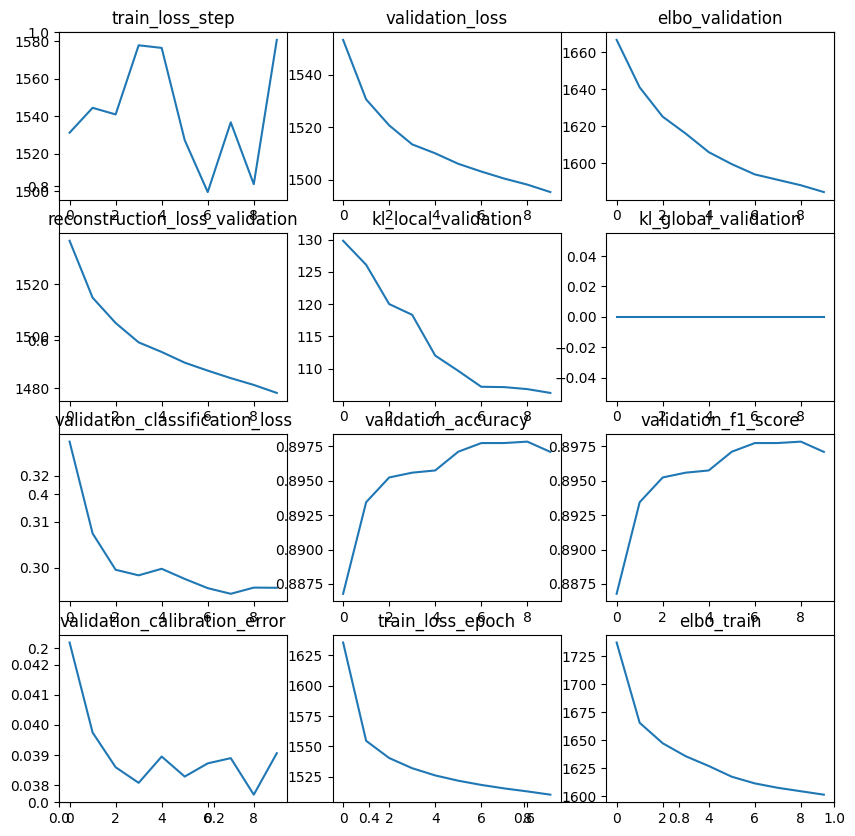

In [31]:
if run_scanvi==True:
    print("RUN SCANVI")
    def run_scvi(adata_hvg, max_epochs, batch_size_vae,CATEGORICAL_COV,PATIENCE=5, N_LATENT=10, N_LAYERS=1):
        DISPERSION =  'gene-batch'
        scvi.model.SCANVI.setup_anndata(adata_hvg, 
                                   #layer="counts",
                                   categorical_covariate_keys=CATEGORICAL_COV,
                                  #continuous_covariate_keys=CONTINUOUS_COV,
                                 batch_key=HVG_BATCH_KEY,
                                  labels_key=SCANVI_LABELS_KEY,
                                        unlabeled_category=SCANVI_UNLABELLED
                                       )
        model = scvi.model.SCANVI(adata_hvg, 
                        dispersion=DISPERSION,
                        n_latent = N_LATENT, 
                        n_layers = N_LAYERS,
                       )
        model.train(accelerator ='gpu', 
                    max_epochs=max_epochs,             
                    early_stopping=True,
                   early_stopping_patience=PATIENCE,
                   batch_size=batch_size_vae)
        print("model trained")
        try:
            count=1
            plt.subplots(figsize=(10, 10))
            for key in model.history.keys():
                plt.subplot(4,3,count)
                plt.plot(model.history[key])
                plt.title(key)
                count+=1
            plt.show()    
        except: 
            print("Error with count")
            try:
                print(count)
            except:
                print("can't print count")
        return adata_hvg, model
elif run_scanvi==False:
    print("RUN scvi")
    sample_key = "sample_id"
    def run_scvi(adata_hvg, max_epochs,  batch_size_vae, CATEGORICAL_COV, PATIENCE=5, N_LATENT=10, N_LAYERS=1):
        DISPERSION = 'gene-batch'
        scvi.model.SCVI.setup_anndata(adata_hvg, 
                              #        layer="counts",
                                        batch_key=HVG_BATCH_KEY,
                                       )
        model = scvi.model.SCVI(adata_hvg, 
                        dispersion=DISPERSION,
                        n_latent = N_LATENT, 
                        n_layers = N_LAYERS,
                       )
        model.train(max_epochs=max_epochs,             
                    early_stopping=True,
                    accelerator='gpu',
                   early_stopping_patience=PATIENCE, #use_gpu =True, 
                   batch_size=batch_size_vae)
        print("model trained")
        try:
            count=1
            plt.subplots(figsize=(10, 10))
            for key in model.history.keys():
                plt.subplot(4,3,count)
                plt.plot(model.history[key])
                plt.title(key)
                count+=1
            plt.show()    
        except: 
            print("Error with count")
            try:
                print(count)
            except:
                print("can't print count")
        return adata_hvg, model

adata, model_test = run_scvi(adata, 
                          max_epochs=MAX_EPOCHS, 
                      batch_size_vae=BATCH_SIZE,
                          CATEGORICAL_COV=CAT_COVS,
                   
                                       N_LATENT=N_LATENT,
                                      N_LAYERS=N_LAYERS,
                                        PATIENCE=EARLY_STOPPING_PATIENCE
                            )

# SAVE MODEL

In [32]:
1

1

In [33]:
if run_scanvi==True:
    BASE_DIR = BASE + f'/SpatialSkinAtlasMapping_scanviSpatialSkinAtlasMapping_{DATASET}_{model_details}/'
    model_test.save(BASE_DIR,
                save_anndata=True,
                 overwrite=True)
else:
    BASE_DIR = BASE + f'/SpatialSkinAtlasMapping_scvi_{DATASET}_{model_details}/'
    model_test.save(BASE_DIR,
                    save_anndata=True,
                 overwrite=True)
print(f"saved to {BASE_DIR}")

saved to /lustre/scratch124/cellgen/haniffa/projects/adult_skin_v1/nobackup_output//SpatialSkinAtlasMapping_scanviSpatialSkinAtlasMapping_AA_VALID_HVGNUMBER6429__MAXEPOCHS10__BATCHKEYsample_id/


# Now, we will re-load original data to cluster

In [34]:
# load data (pre-HVG selection)
print(f"trained. now re-load adata: {adata_path}")
adata=sc.read_h5ad(adata_path)

trained. now re-load adata: /lustre/scratch124/cellgen/haniffa/projects/adult_skin_v1/nobackup_output/adata_AA_VALID_and_SpatialSkinAtlas_preintegration.h5ad


/software/cellgen/team298/ls34/scpoli/lib/python3.11/site-packages/anndata/_core/anndata.py:1818: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


In [35]:
# attach scanvi embeddings + predictions
latent = model_test.get_latent_representation() 
adata.obsm["X_scanvi"] = latent


try:
    adata.obs["scanvi_predictions"]=preds
except:
    try:
        preds = model_test.predict(adata)
        adata.obs["scanvi_predictions"]=preds
    except:
        1
    try:
        preds = model_test.predict()
        adata.obs["scanvi_predictions"]=preds
    except:
        1

INFO     Input AnnData not setup with scvi-tools. attempting to transfer AnnData setup                             


In [36]:
import gc
gc.collect()

32856

#  knn -> umap -> save

In [37]:
# Note here that we include the atlas data in KNN construction. Alternatively this can be excluded, but we found
# good results through including it.
neighbor_id = f"neighbor_{NEIGHBOR}"   
print("start neighbours")
sc.pp.neighbors(adata, use_rep = 'X_scanvi', metric = "euclidean", n_neighbors=NEIGHBOR,key_added=neighbor_id)
print("neighbours done")
print("start umap")
sc.tl.umap(adata, min_dist=MIN_DIST, neighbors_key =neighbor_id )

start neighbours
neighbours done
start umap


In [38]:
# save to dir with model
SAVE_PATH = BASE_DIR + f'adata_{DATASET}+{model_details}.h5ad'
adata.write(SAVE_PATH,  compression="gzip")
print(f"Saved to {SAVE_PATH}")
from datetime import datetime
now = datetime.now()
timestamp = now.strftime("%Y-%m-%d %H:%M:%S")
print(f"Saved! Time: {timestamp}")
 

Saved to /lustre/scratch124/cellgen/haniffa/projects/adult_skin_v1/nobackup_output//SpatialSkinAtlasMapping_scanviSpatialSkinAtlasMapping_AA_VALID_HVGNUMBER6429__MAXEPOCHS10__BATCHKEYsample_id/adata_AA_VALID+HVGNUMBER6429__MAXEPOCHS10__BATCHKEYsample_id.h5ad
Saved! Time: 2026-03-13 01:14:30


# Visualise output

In [39]:
# stop

In [1]:
2


2

In [5]:
DATASET="AA_VALID"

In [6]:
import scanpy as sc
adata=sc.read_h5ad('/lustre/scratch124/cellgen/haniffa/projects/adult_skin_v1/nobackup_output//SpatialSkinAtlasMapping_scanviSpatialSkinAtlasMapping_AA_VALID_HVGNUMBER6429__MAXEPOCHS10__BATCHKEYsample_id/adata_AA_VALID+HVGNUMBER6429__MAXEPOCHS10__BATCHKEYsample_id.h5ad')


/software/cellgen/team298/ls34/scpoli/lib/python3.11/site-packages/anndata/_core/anndata.py:1818: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


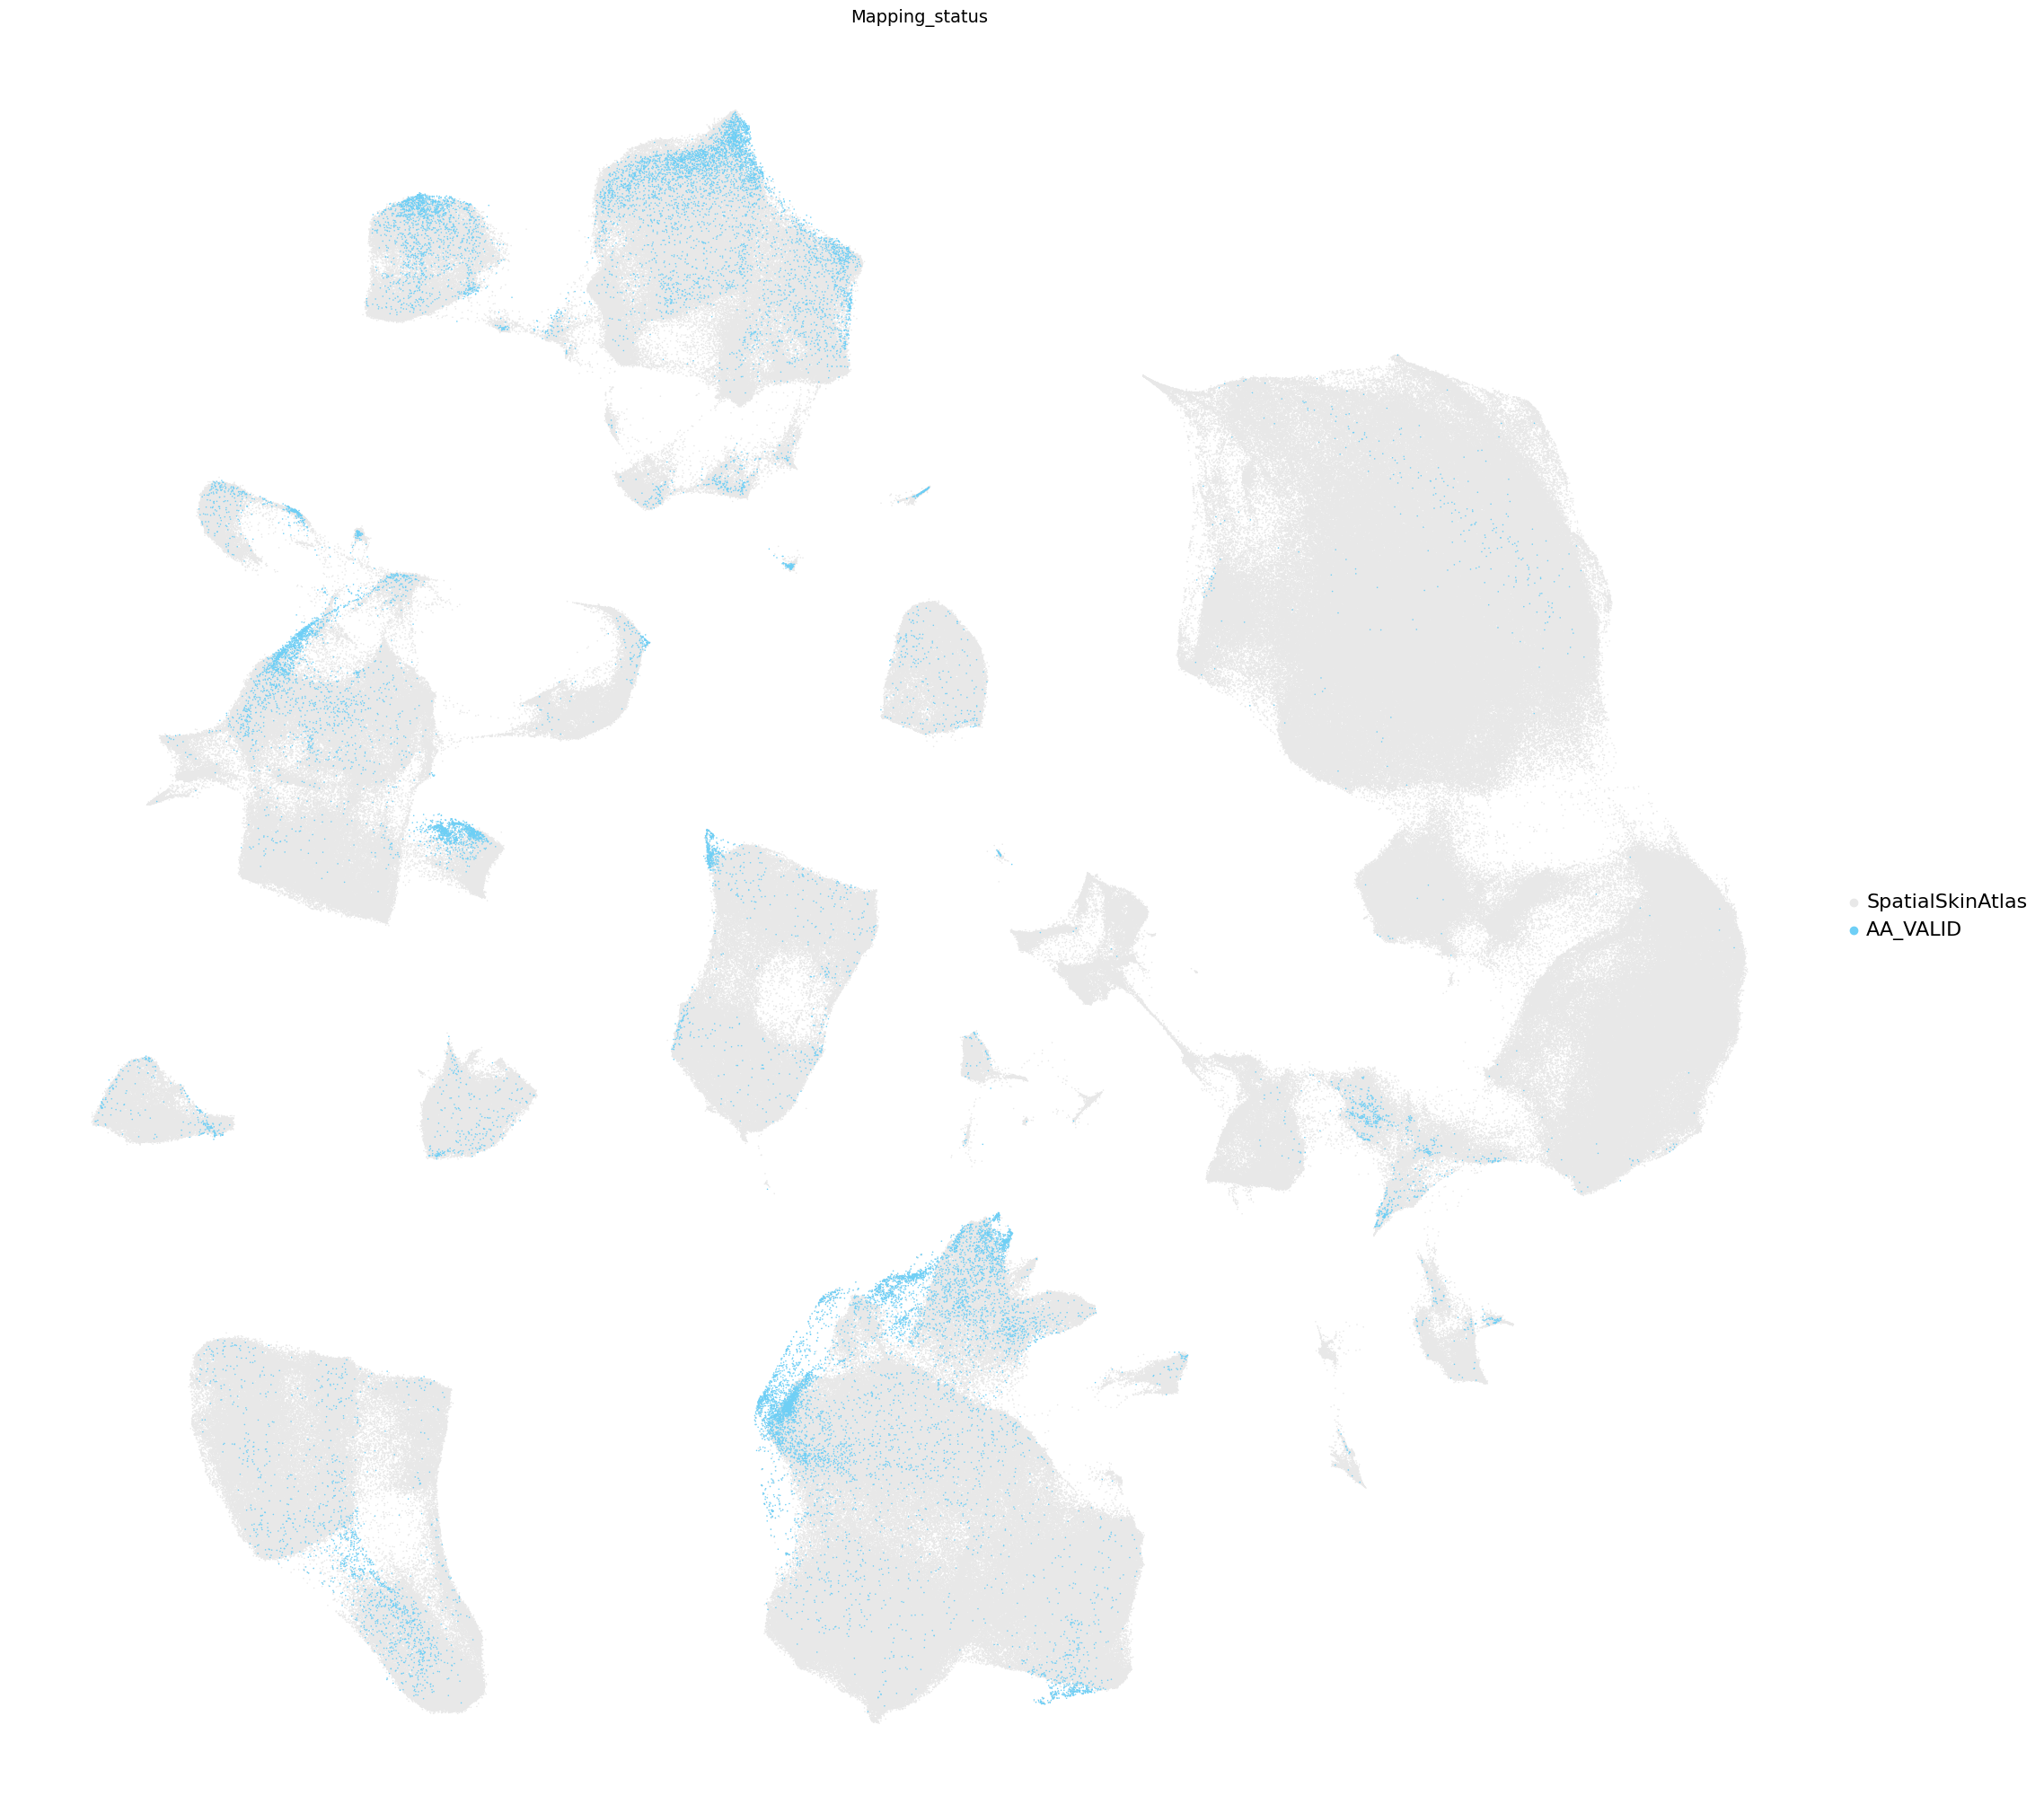

In [14]:
"""
Show how new data maps to atlas. Note that if no QC has been performed, a low QC cluster often forms (but in this dataset, QC had already been performed)

Looks like a good outcome! what a relief
"""

sc.settings.set_figure_params(dpi=50, dpi_save=300, facecolor="white", frameon=False, figsize=(26,26))

sc.pl.umap(
    adata,
    color=[
        'Mapping_status',  
    ],
    #legend_loc="on data",
    s=5, 
    legend_fontoutline=2,
    legend_fontsize=16,

       palette = {
    "SpatialSkinAtlas": "#E8E8E8",   
    DATASET: "#6ECFF6"            # swaecation sky blue
}      , save="aa_validation_int.pdf"   
)



In [9]:
!wget "https://raw.githubusercontent.com/haniffalab/spatial_skin_atlas/main/misc/color_for_adult_skin2.pkl" \
     -O color_for_adult_skin2.pkl

import pickle
file_path = "./color_for_adult_skin2.pkl"

with open(file_path, "rb") as f:
    colors = pickle.load(f)
colors= colors | {'New/unlabelled/excluded': "#C8C8C8"}
print(f"Loaded {len(colors)} colour entries")

--2026-03-13 07:35:25--  https://raw.githubusercontent.com/haniffalab/spatial_skin_atlas/main/misc/color_for_adult_skin2.pkl
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.109.133, 185.199.108.133, 185.199.111.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.109.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 4369 (4.3K) [application/octet-stream]
Saving to: ‘color_for_adult_skin2.pkl’

color_for_adult_ski 100%[===================>]   4.27K  --.-KB/s    in 0s      

2026-03-13 07:35:25 (39.7 MB/s) - ‘color_for_adult_skin2.pkl’ saved [4369/4369]

Loaded 195 colour entries


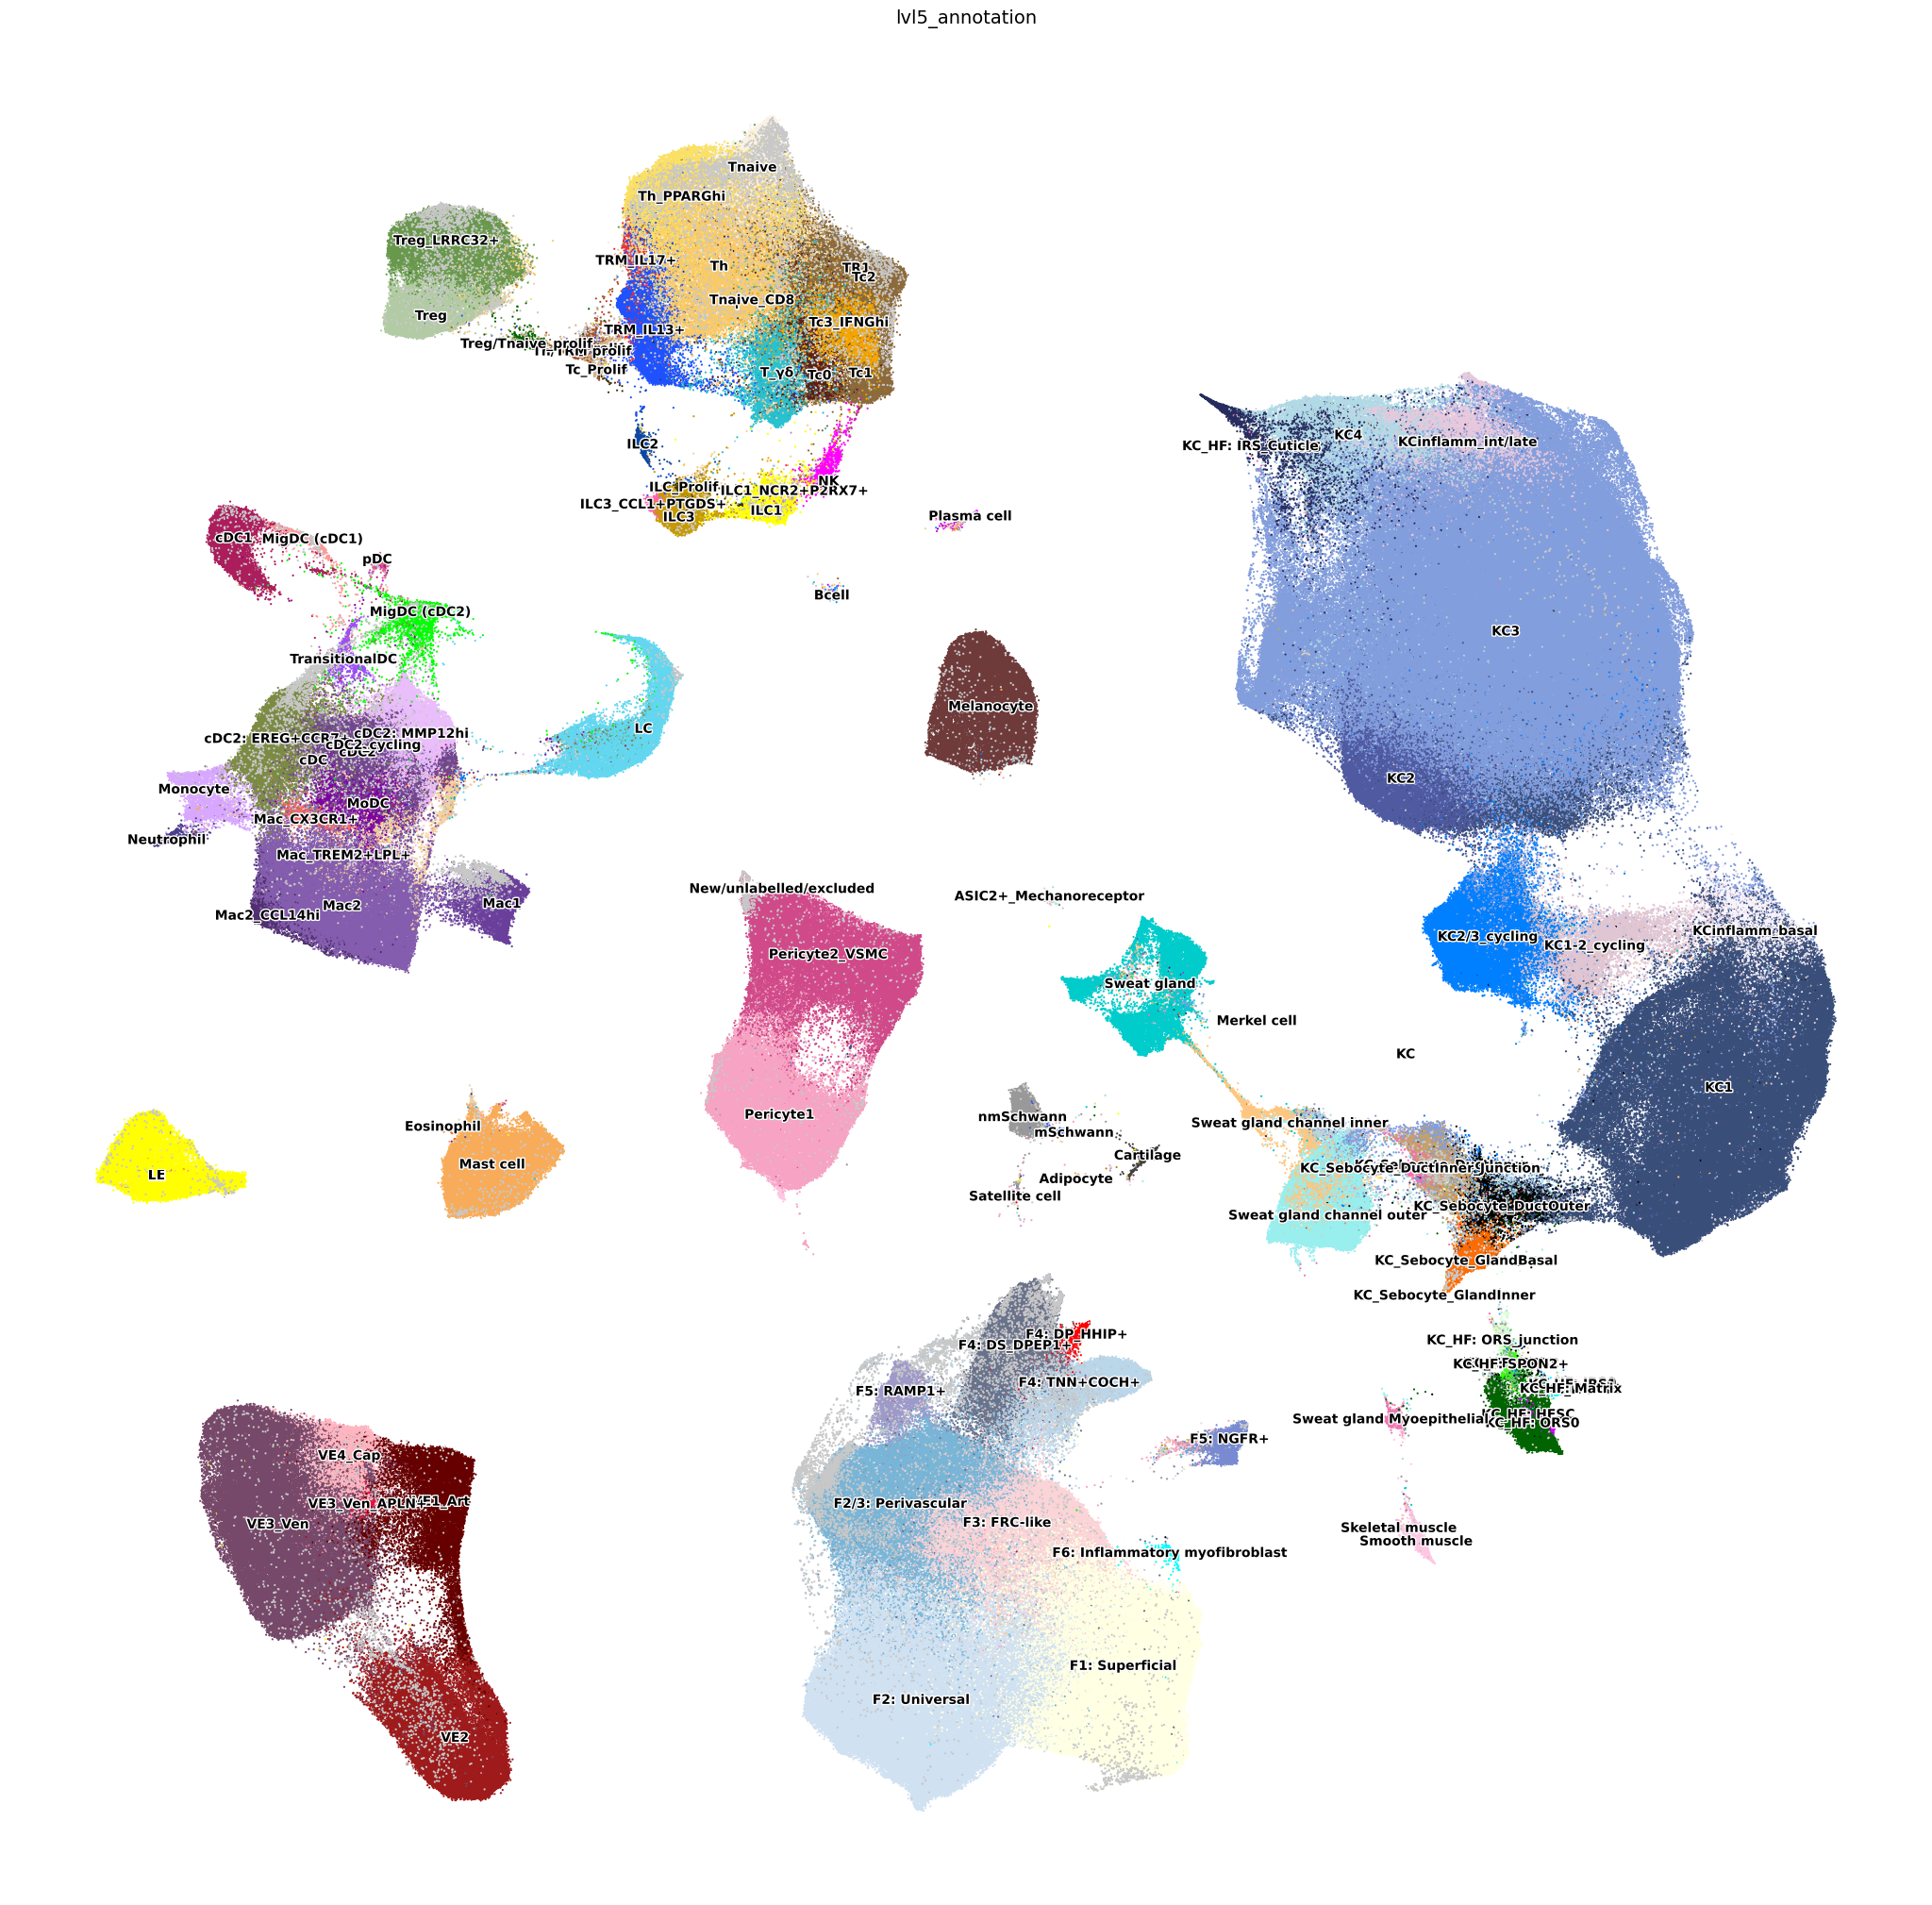

In [10]:
adata.obs["lvl5_annotation"] = (
    adata.obs["lvl5_annotation"]
    .astype("category")
    .cat.add_categories(["NA"])
    .fillna("NA")
)

colors["NA"] = "#6ECFF6"   # sky blue or whatever

sc.pl.umap(
    adata,
    color="lvl5_annotation",
    legend_loc="on data",
    s=10,
    legend_fontsize=10,
    legend_fontoutline=2,
    palette=colors
)

Loaded 196 colour entries


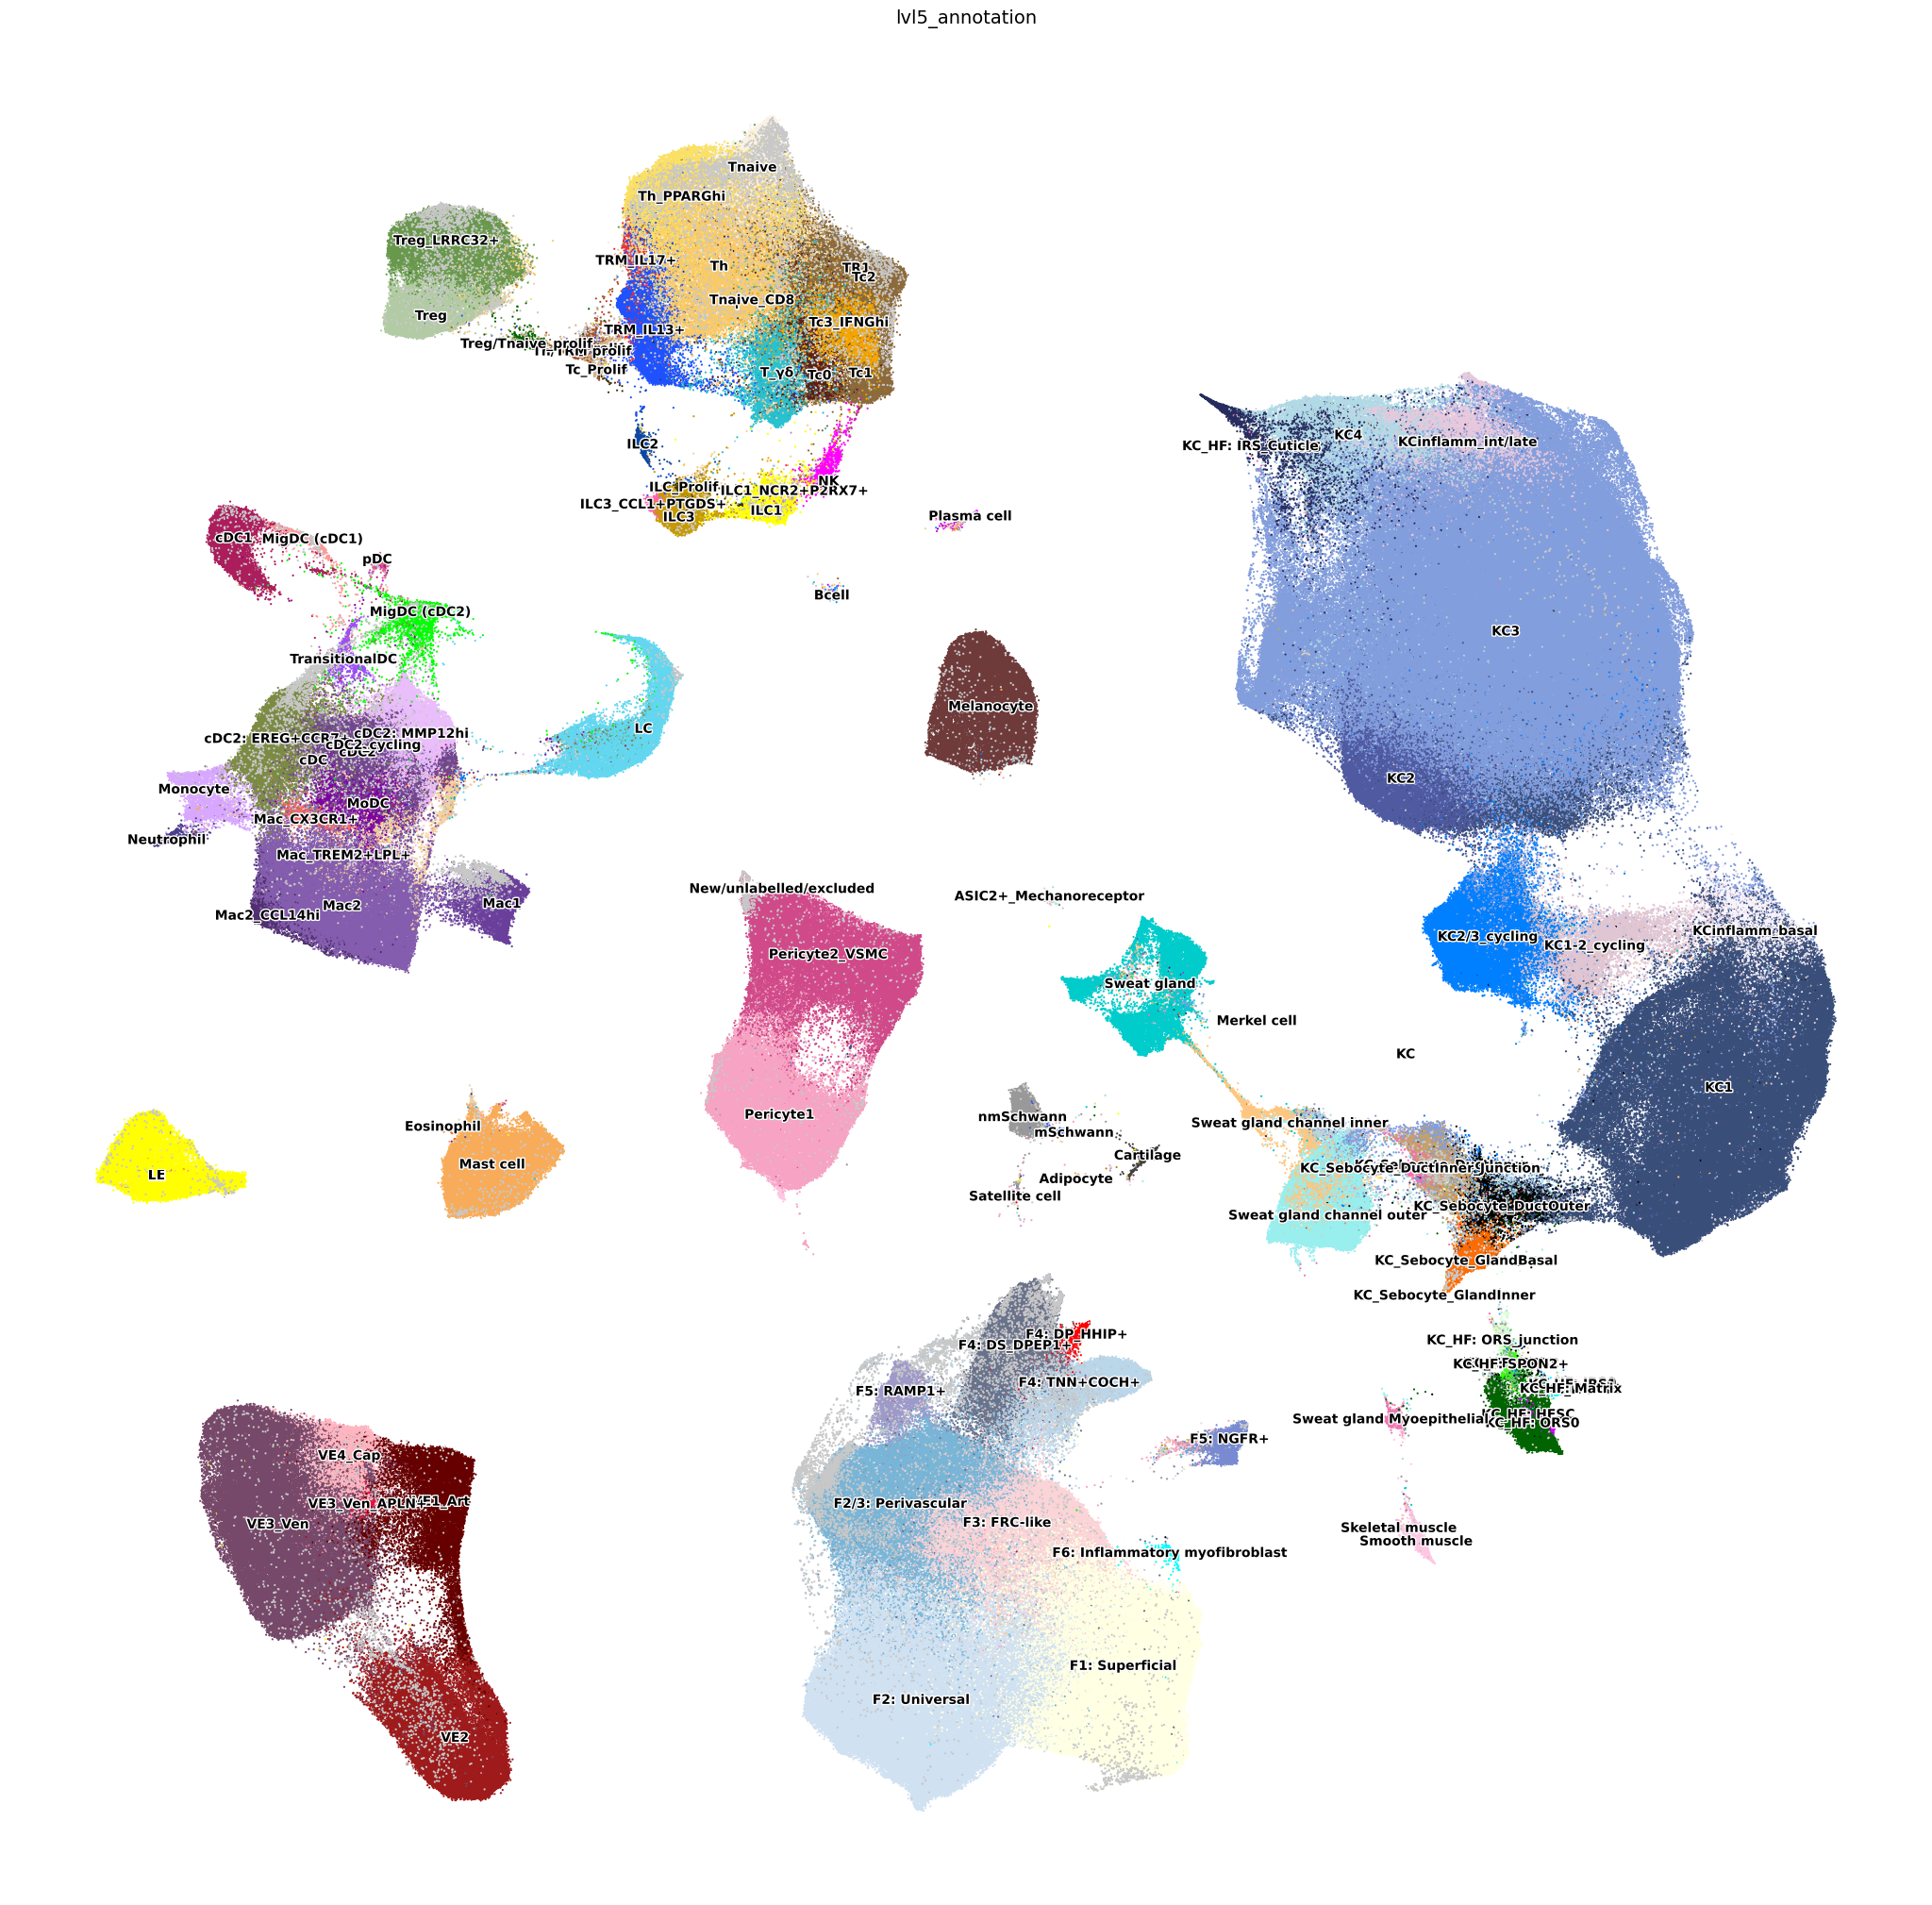

In [11]:
sc.settings.set_figure_params(dpi=50, dpi_save=300, facecolor="white", frameon=False, figsize=(26,26))

try:
    print(f"Loaded {len(colors)} colour entries")
    sc.pl.umap(
        adata,
        color=["lvl5_annotation"],
        legend_loc="on data",
        s=10,
        legend_fontsize=10,
        legend_fontoutline=2,
        show=False,
        palette=colors, 
        #fillna_color= "#6ECFF6" 
    )
except:
    try:
        import glasbey
        key = "lvl5_annotation"
        cats = adata.obs[key].astype("category").cat.categories
        palette = glasbey.create_palette(palette_size=len(cats), as_hex=True)
        adata.uns[f"{key}_colors"] = palette

        sc.pl.umap(
        adata,
        color=[key],
        legend_loc="on data",
        s=10,
        legend_fontsize=10,
        legend_fontoutline=2,
        show=False,
        palette=colors
    ) 
    except:
        sc.pl.umap(
        adata,
        color=[key],
        legend_loc="on data",
        s=10,
        legend_fontsize=10,
        legend_fontoutline=2,
        show=False,
    ) 




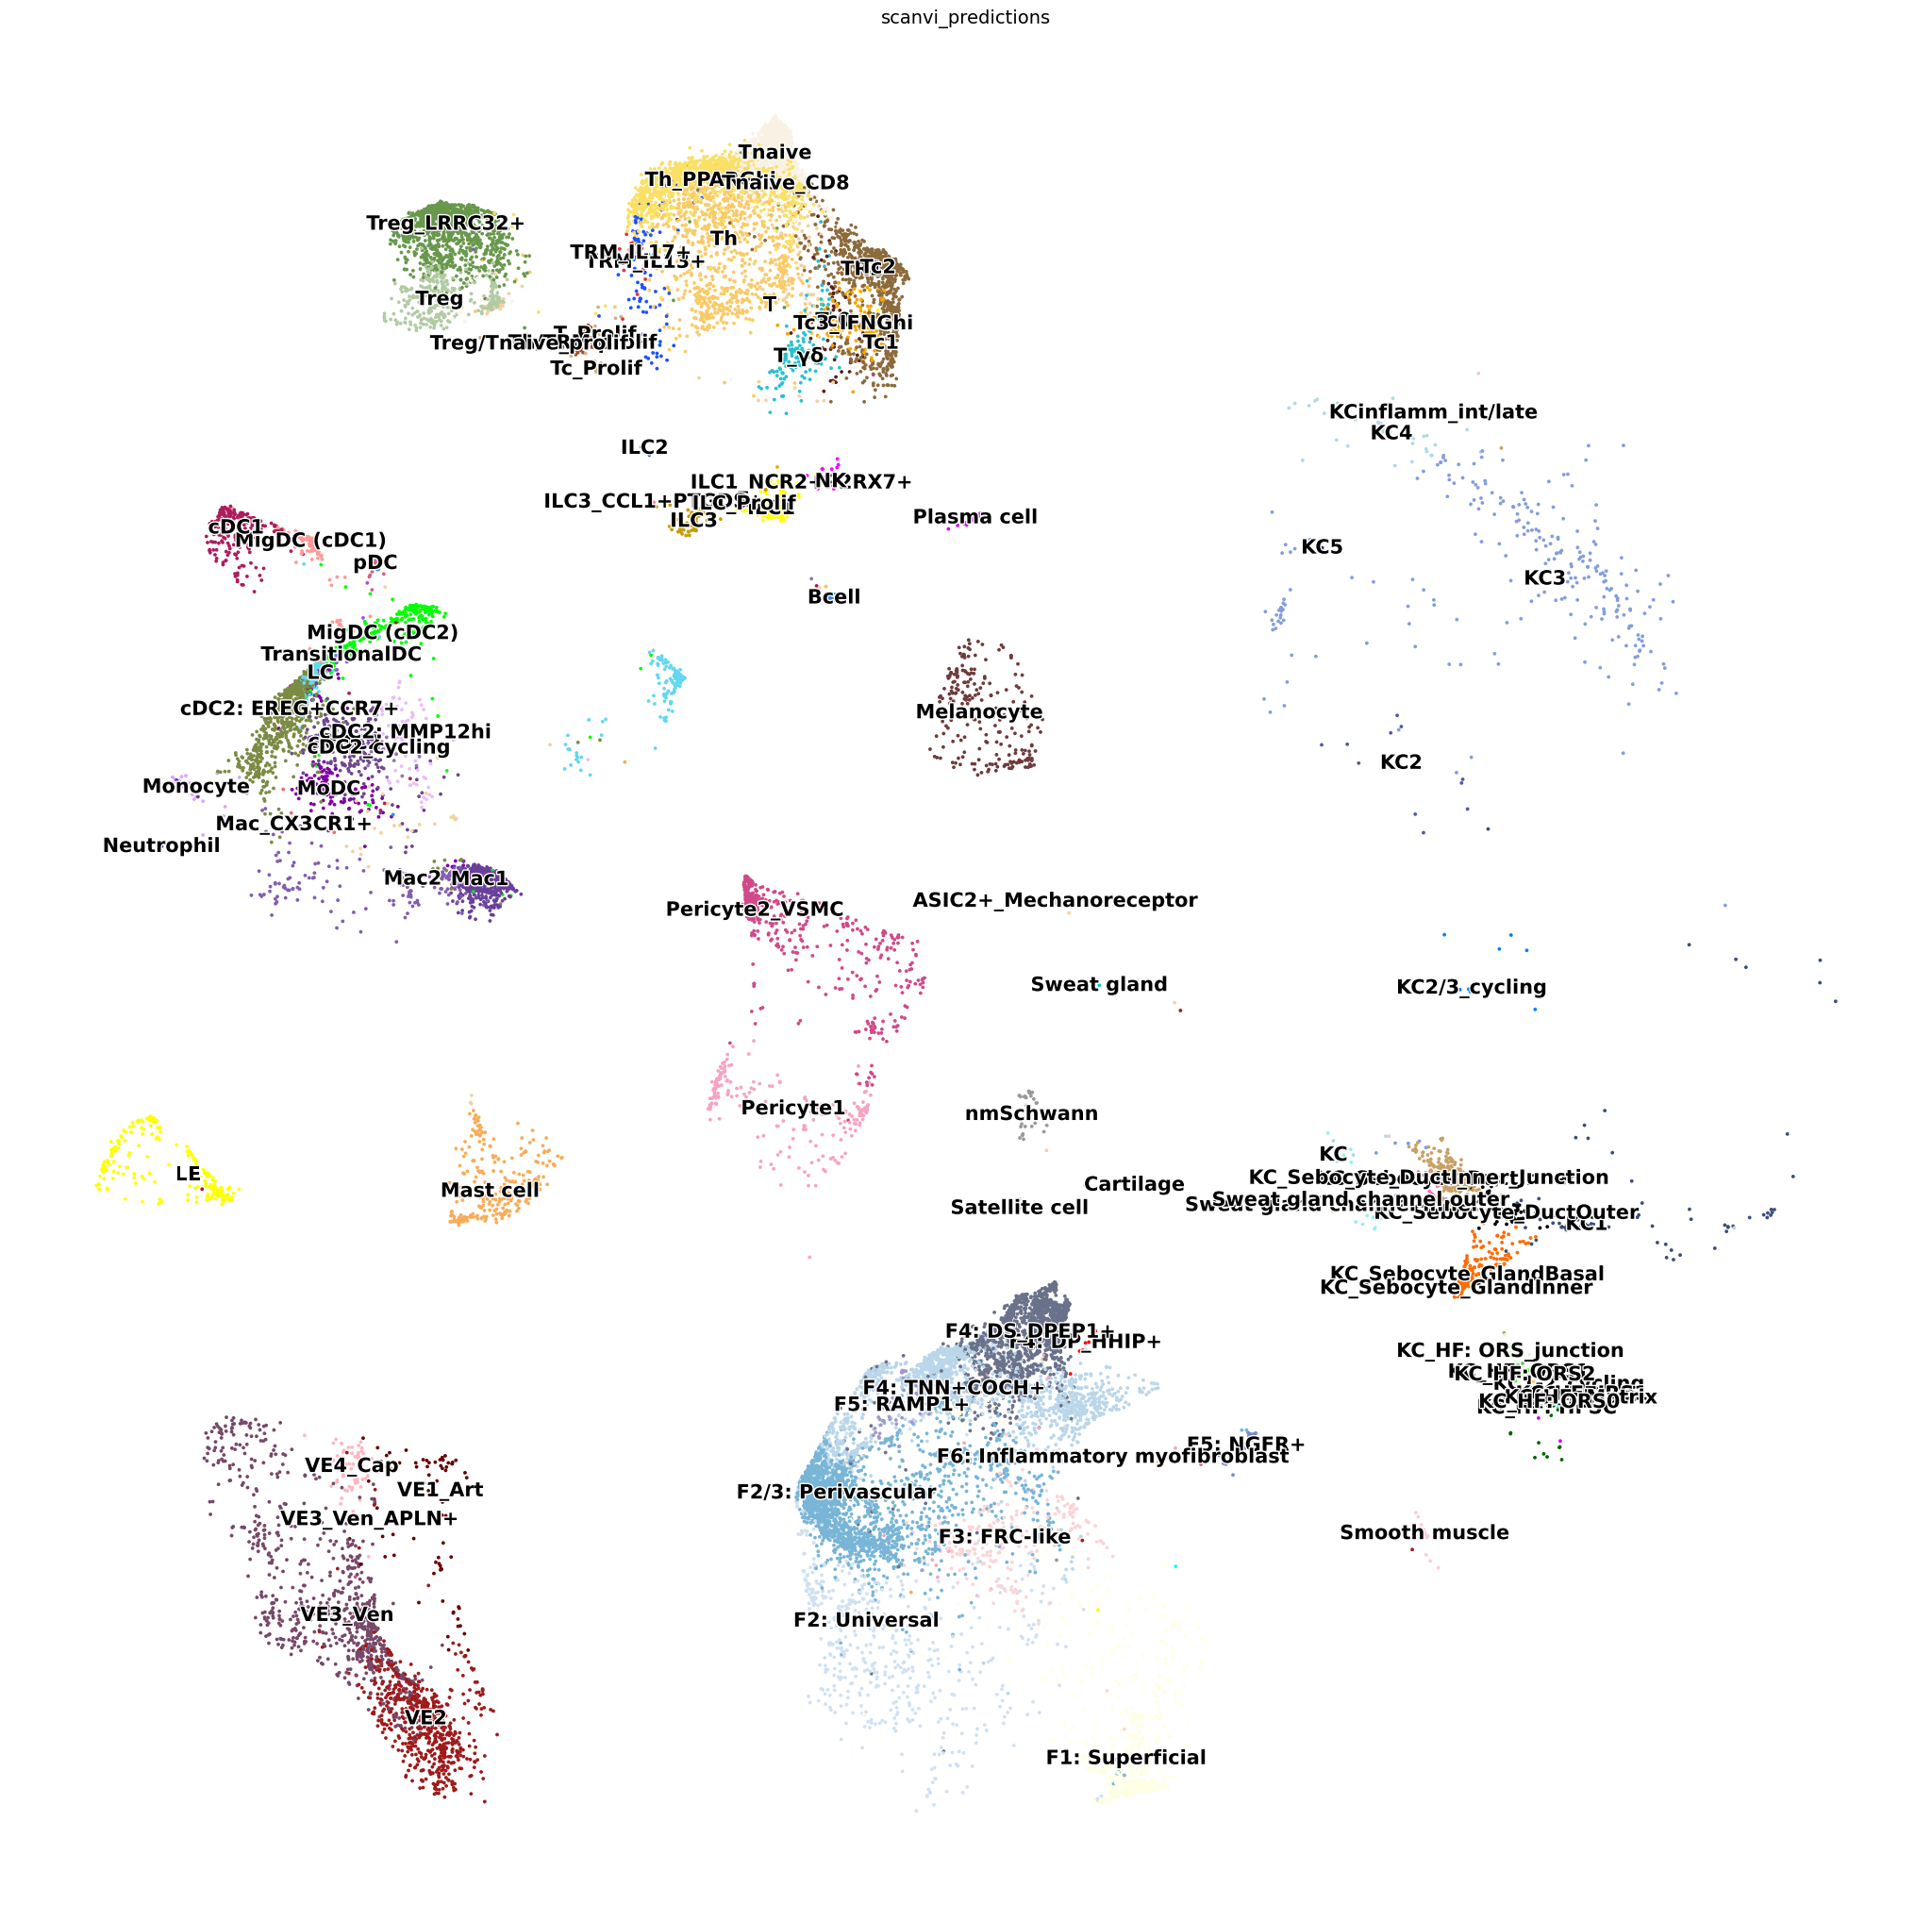

In [16]:
"""
We can also see what scanvi predictions are, but in my experience these have not been too reliable
compared to manually annotating the data.

However, not too bad for a quick overview.
"""
#sc.settings.set_figure_params(dpi=50, dpi_save=300, facecolor="white", frameon=False, figsize=(16,16))
sc.settings.set_figure_params(dpi=50, dpi_save=300, facecolor="white", frameon=False, figsize=(26,26))

adata_mappeddata=adata[adata.obs["Mapping_status"]!="SpatialSkinAtlas"].copy()
sc.pl.umap(
    adata_mappeddata,
    color=[
        'scanvi_predictions',  
    ],
    legend_loc="on data",
    s=30, 
    legend_fontoutline=2,
    legend_fontsize=15,
    palette=colors,
    save="mapped_AAvalidation.pdf"

)


In [48]:
# Normalise for plotting gene expression 
## NOTE THAT THIS OVERWRITES COUNT DATA SO WILL NOT SAVE AFTER THIS
sc.pp.normalize_total(adata_mappeddata, target_sum=1e4)
sc.pp.log1p(adata_mappeddata)

In [18]:
adata_mappeddata = adata_mappeddata[(adata_mappeddata.obs["scanvi_predictions"].str.startswith("T"))|
                           (adata_mappeddata.obs["scanvi_predictions"].str.startswith("NK"))|
                           (adata_mappeddata.obs["scanvi_predictions"].str.startswith("ILC"))
            
                          ].copy()
adata_mappeddata=adata_mappeddata[adata_mappeddata.obs["scanvi_predictions"]!="TransitionalDC"]

In [63]:
adata_mappeddata.write('/lustre/scratch124/cellgen/haniffa/projects/adult_skin_v1/nobackup_output//SpatialSkinAtlasMapping_scanviSpatialSkinAtlasMapping_AA_VALID_HVGNUMBER6429__MAXEPOCHS10__BATCHKEYsample_id/adata_tcellsonly_norm.h5ad')


In [28]:
{x:x for x in adata_mappeddata.obs["scanvi_predictions"].unique()}

{'Th/TRM prolif': 'Th/TRM prolif',
 'ILC_Prolif': 'ILC_Prolif',
 'Treg/Tnaive_prolif': 'Treg/Tnaive_prolif',
 'TRM_IL13+': 'TRM_IL13+',
 'T': 'T',
 'Th_PPARGhi': 'Th_PPARGhi',
 'ILC1': 'ILC1',
 'Treg': 'Treg',
 'Treg_LRRC32+': 'Treg_LRRC32+',
 'Tnaive': 'Tnaive',
 'Tnaive_CD8': 'Tnaive_CD8',
 'Tc0': 'Tc0',
 'ILC3': 'ILC3',
 'Tc3_IFNGhi': 'Tc3_IFNGhi',
 'Th': 'Th',
 'Tc1': 'Tc1',
 'T_γδ': 'T_γδ',
 'Tc2': 'Tc2',
 'ILC2': 'ILC2',
 'TR1': 'TR1',
 'TRM_IL17+': 'TRM_IL17+',
 'NK': 'NK',
 'ILC1_NCR2+P2RX7+': 'ILC1_NCR2+P2RX7+',
 'T_Prolif': 'T_Prolif',
 'Tc_Prolif': 'Tc_Prolif',
 'ILC3_CCL1+PTGDS+': 'ILC3_CCL1+PTGDS+'}

In [50]:
RENAME = {'Th/TRM prolif': 'Th/TRM prolif',
 'ILC_Prolif': 'ILC_Prolif',
 'Treg/Tnaive_prolif': 'Treg/Tnaive_prolif',
 'TRM_IL13+': 'TRM_IL13+',
 'T': 'T',
 'Th_PPARGhi': 'Th_PPARGhi',
 'ILC1': 'ILC1',
 'Treg': 'Treg',
 'Treg_LRRC32+': 'Treg_LRRC32+',
 'Tnaive': 'Tnaive',
 'Tnaive_CD8': 'Tnaive',
 'Tc0': 'Tc0',
 'ILC3': 'ILC3',
 'Tc3_IFNGhi': 'Tc3_IFNGhi',
 'Th': 'Th',
 'Tc1': 'Tc1',
 'T_γδ': 'T_γδ',
 'Tc2': 'Tc2',
 'ILC2': 'ILC2',
 'TR1': 'TR1',
 'TRM_IL17+': 'TRM_IL17+',
 'NK': 'NK',
 'ILC1_NCR2+P2RX7+': 'ILC1',
 'T_Prolif': 'T_Prolif',
 'Tc_Prolif': 'Tc_Prolif',
 'ILC3_CCL1+PTGDS+': 'ILC3'}
adata_mappeddata.obs["provisional"]=adata_mappeddata.obs["scanvi_predictions"].map(RENAME)

In [62]:
RENAME = {'Th/TRM prolif': 'T_Prolif',
 'ILC_Prolif': 'ILC_Prolif',
 'Treg/Tnaive_prolif': 'T_Prolif',
 'TRM_IL13+': 'TRM_IL13+',
 'T': 'T',
 'Th_PPARGhi': 'Th_PPARGhi',
 'ILC1': 'ILC1',
 'Treg': 'Treg',
 'Treg_LRRC32+': 'Treg_LRRC32+',
 'Tnaive': 'Tnaive',
 'Tnaive_CD8': 'Tnaive',
 'Tc0': 'Tc0',
 'ILC3': 'ILC3',
 'Tc3_IFNGhi': 'Tc3_IFNGhi',
 'Th': 'Th',
 'Tc1': 'Tc1',
 'T_γδ': 'T_γδ',
 'Tc2': 'Tc2',
 'ILC2': 'ILC2',
 'TR1': 'TR1',
 'TRM_IL17+': 'TRM_IL17+',
 'NK': 'NK',
 'ILC1_NCR2+P2RX7+': 'ILC1',
 'T_Prolif': 'T_Prolif',
 'Tc_Prolif': 'T_Prolif',
 'ILC3_CCL1+PTGDS+': 'ILC3'}
adata_mappeddata.obs["provisional2"]=adata_mappeddata.obs["scanvi_predictions"].map(RENAME)

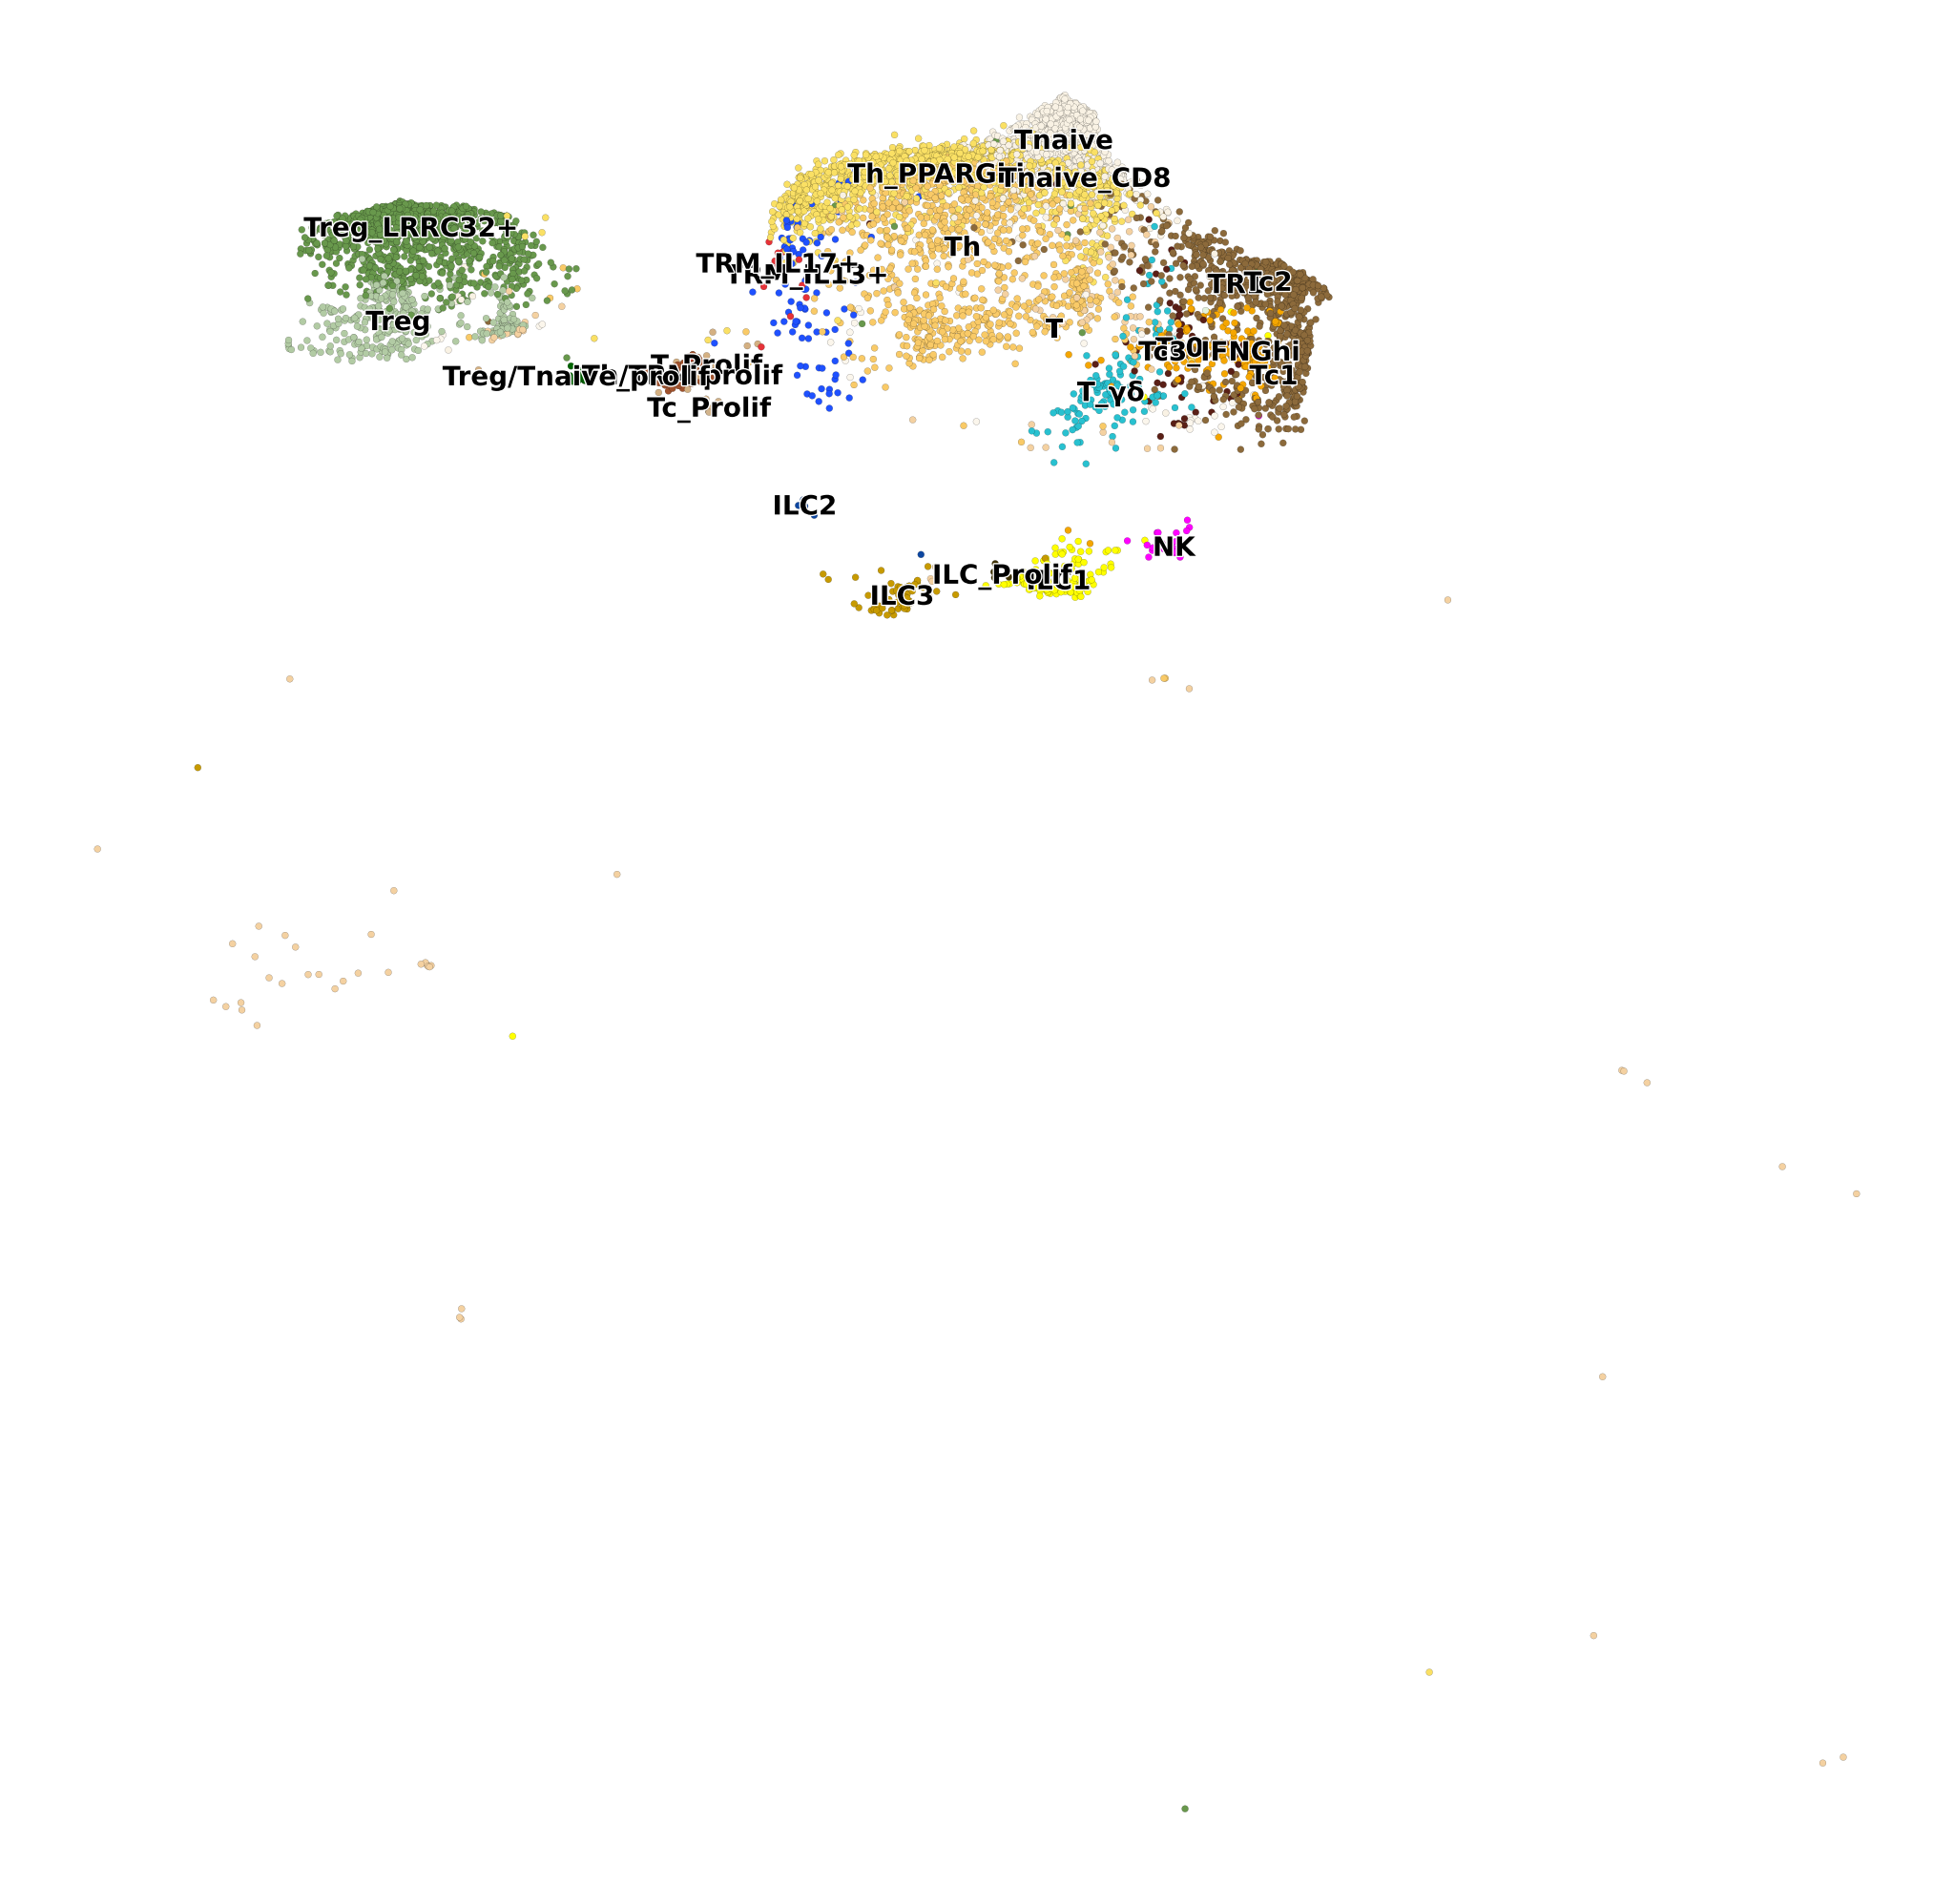

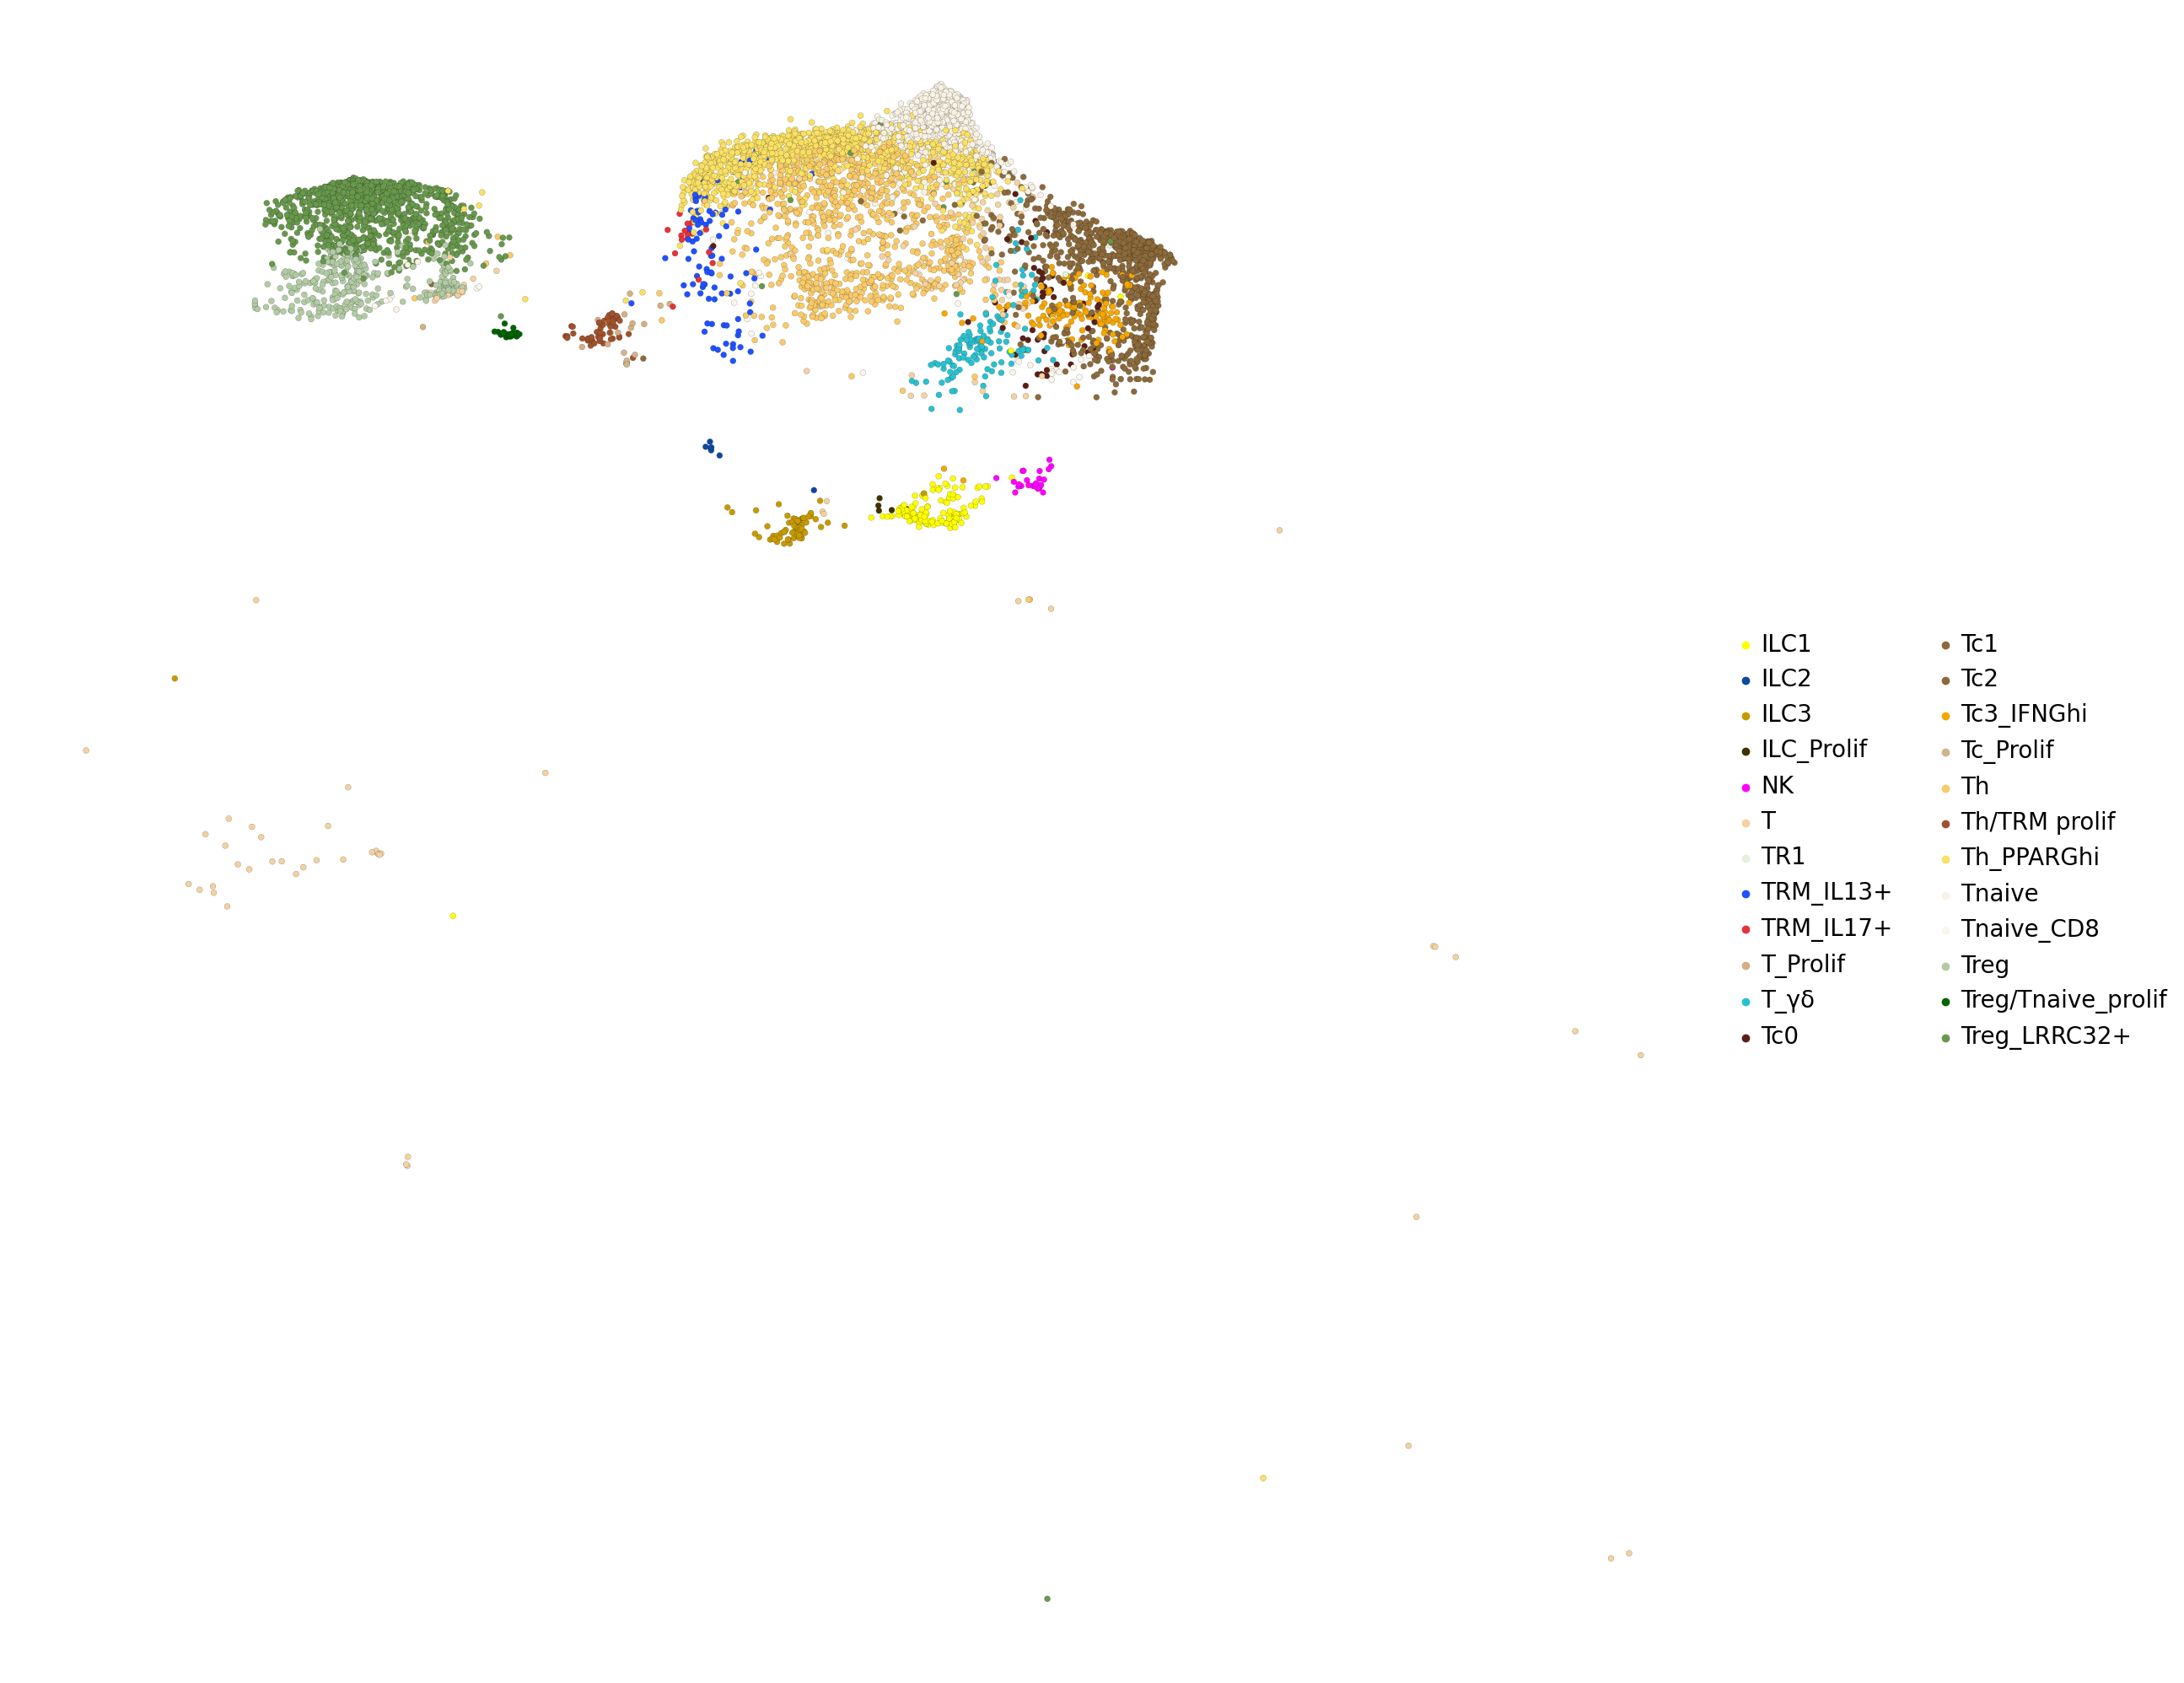

In [40]:
sc.pl.umap(
adata_mappeddata,
    color=[
    'provisional',
],
legend_loc="on data",
s=100,
    legend_fontsize=20,
    legend_fontoutline=2,
    edgecolor='black',
    linewidth=.1,
    title='',
        palette=colors,
save="AA_validation_UMAP_Tcells.pdf"
#legend_fontsize=10)
) 


sc.pl.umap(
adata_mappeddata,
    color=[
    'provisional',
],
#legend_loc="on data",
s=100,
    legend_fontsize=20,
    legend_fontoutline=2,
    edgecolor='black',
    linewidth=.1,
    title='',
    palette=colors,
    #save="6b_AA.pdf"
#legend_fontsize=10)
) 
# sc.pl.umap(
# adata_mappeddata,
#     color=[
#     'provisional',
# ],
# #legend_loc="on data",
# s=40,
#     legend_fontsize=8,
#     legend_fontoutline=2,
#     edgecolor='black',
#     linewidth=.1,
#     title='',
#    # save="6b_AA_smallerdots.pdf"
# #legend_fontsize=10)
# ) 



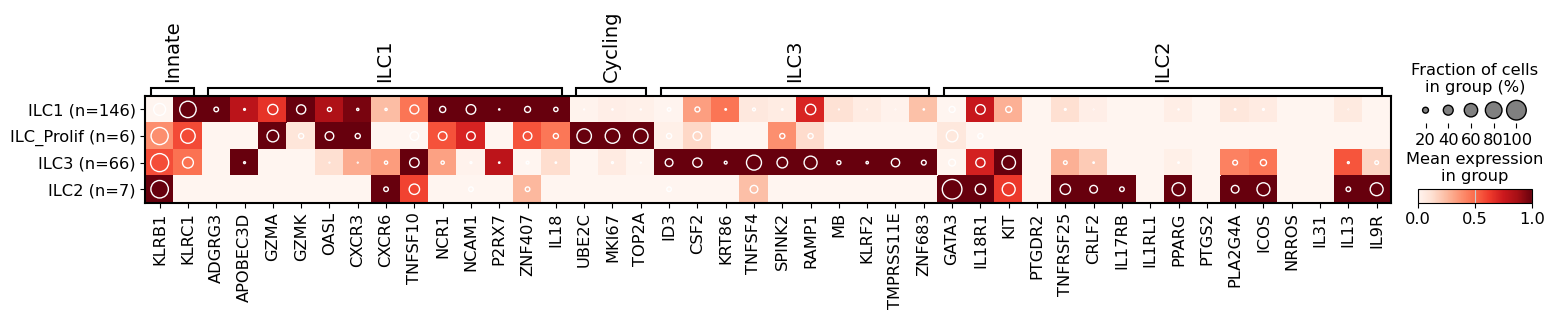

In [59]:
ALLT2 = {'Innate': [
  'KLRB1',
  'KLRC1',
  #'TYROBP',
  #'FCER1G',
],
#          "NK/ILC1": ['PRF1','KLRD1','TBX21','IRF8',  'KLRF1',
#   'KLRG1','KLRC2',
#   'KLRC3', 'CEBPD',"FGR", "EOMES", "IFNG", 'SLA2', 'KIR2DL4', 'SH2D1B', 'SLFN13', 'TMIGD2'],
# #  'NK': [  'FCGR3A',
 
# #   'CX3CR1',
# #   'CCL4L2',
# #   'PRSS23', 'B3GAT1',
# #        'SPON2',
# #   'S1PR5',
# #   'AKR1C3',
# #          'FGFBP2',



# #   'S100B'],

         "ILC1": [ "ADGRG3", "APOBEC3D", "GZMA", 'GZMK', 'OASL',  "CXCR3", 'CXCR6' , "TNFSF10" ,
                  'NCR1','NCAM1','P2RX7','ZNF407','IL18',],
                   'Cycling': ['UBE2C', 'MKI67', 'TOP2A'],

          'ILC3': ['ID3','CSF2', 'KRT86',
 # 'ZBTB46',
  'TNFSF4',
  'SPINK2',
  'RAMP1',
  'MB',
  'KLRF2',
  'TMPRSS11E', "ZNF683"],
         
           # 'PTGDS': [  'PTGDS', 'PDLIM4', 'CCL1', 'IL1RN', 'PTGS1', 'PTP4A1'],


 #'ILC2+3': ['IL9R', 'TNFSF11'],

 'ILC2': ['GATA3',  'IL18R1','KIT', 'PTGDR2', 'TNFRSF25',
          'CRLF2',
  'IL17RB',
  'IL1RL1',

  'PPARG',
  'PTGS2',
  'PLA2G4A',
  #'IL4',

  'ICOS',
  'NRROS',     'IL31',
#'IL22',
          'IL13',# "IL5",#'PDLIM4', 'CCL1',
          #'AREG', 'CCR8',
          'IL9R'],
 # 'Naive/Tcm': ['SELL', 'CCR7', 'S1PR1', 'TCF7', 'PAK2', 'ZHX2'],
 #        "NEW": ["PLXDC2", "AIF1", "RAB34", "NEDD4L", "PM20D2", "TNRC18", "JCHAIN", ],
 #        "RORC+": ["RORC",]
        }

 


CATEGORY = "provisional"
           

adata_iiii = adata_mappeddata[adata_mappeddata.obs["provisional"].str.startswith("ILC")]   
    
counts = adata_iiii.obs[CATEGORY].value_counts()
valid_statuses = counts[counts >= 1].index
adata_iiii = adata_iiii[adata_iiii.obs[CATEGORY].isin(valid_statuses)].copy()
counts = adata_iiii.obs[CATEGORY].value_counts()
label_map = {group: f"{group} (n={count})" for group, count in counts.items()}
adata_iiii.obs["Patient_status_labeled"] = adata_iiii.obs[CATEGORY].map(label_map)
sorted_labels = [label_map[g] for g in counts.index]

#ORDER=['NK (n=38)', 'ILC1 (n=55)', 'ILC3 (n=48)', 'ILC_Prolif (n=5)', 'ILC2 (n=7)']

# sc.pl.DotPlot(
#     adata_iiii,  
#        ALLT2,
#     #swap_axes=True,
#     groupby="Patient_status_labeled",
#  #  vmax=.8,
    
#         categories_order=ORDER,  # <<— force your order here

 
#     #    colorbar_title='Mean expression\n(variance scaled)', 
#    standard_scale="var",
#    # categories_order=["Treg", "Treg_LRRC32+", "TR1"]
# ) \
#     .style(cmap='Reds', color_on='square', dot_edge_color='white', dot_edge_lw=1, grid=False, #vmax=.8
#                dot_max=1,   

#           )\
# .show()

dp = sc.pl.DotPlot(
    adata_iiii,  
       ALLT2,
    #swap_axes=True,
    groupby="Patient_status_labeled",
 #  vmax=.8,
    
        categories_order=[
                          'ILC1 (n=146)','ILC_Prolif (n=6)', 'ILC3 (n=66)',  'ILC2 (n=7)']
,  # <<— force your order here

 
    #    colorbar_title='Mean expression\n(variance scaled)', 
   standard_scale="var",
   # categories_order=["Treg", "Treg_LRRC32+", "TR1"]
)
dp = dp.style(cmap='Reds', color_on='square', dot_edge_color='white', dot_edge_lw=1, grid=False, #vmax=.8
               dot_max=1)  

          
#dp.show()   
dp.savefig("AA_ILC_VALIDATION.pdf", dpi=300)       
    

In [60]:
adata_iiii.obs.dataset_id.value_counts()

dataset_id
AA_NY_GSE233906    225
Name: count, dtype: int64

In [33]:
adata_iiii.obs["Patient_status_labeled"].unique()

['ILC_Prolif (n=6)', 'ILC1 (n=146)', 'ILC3 (n=66)', 'ILC2 (n=7)']
Categories (4, object): ['ILC1 (n=146)', 'ILC2 (n=7)', 'ILC3 (n=66)', 'ILC_Prolif (n=6)']

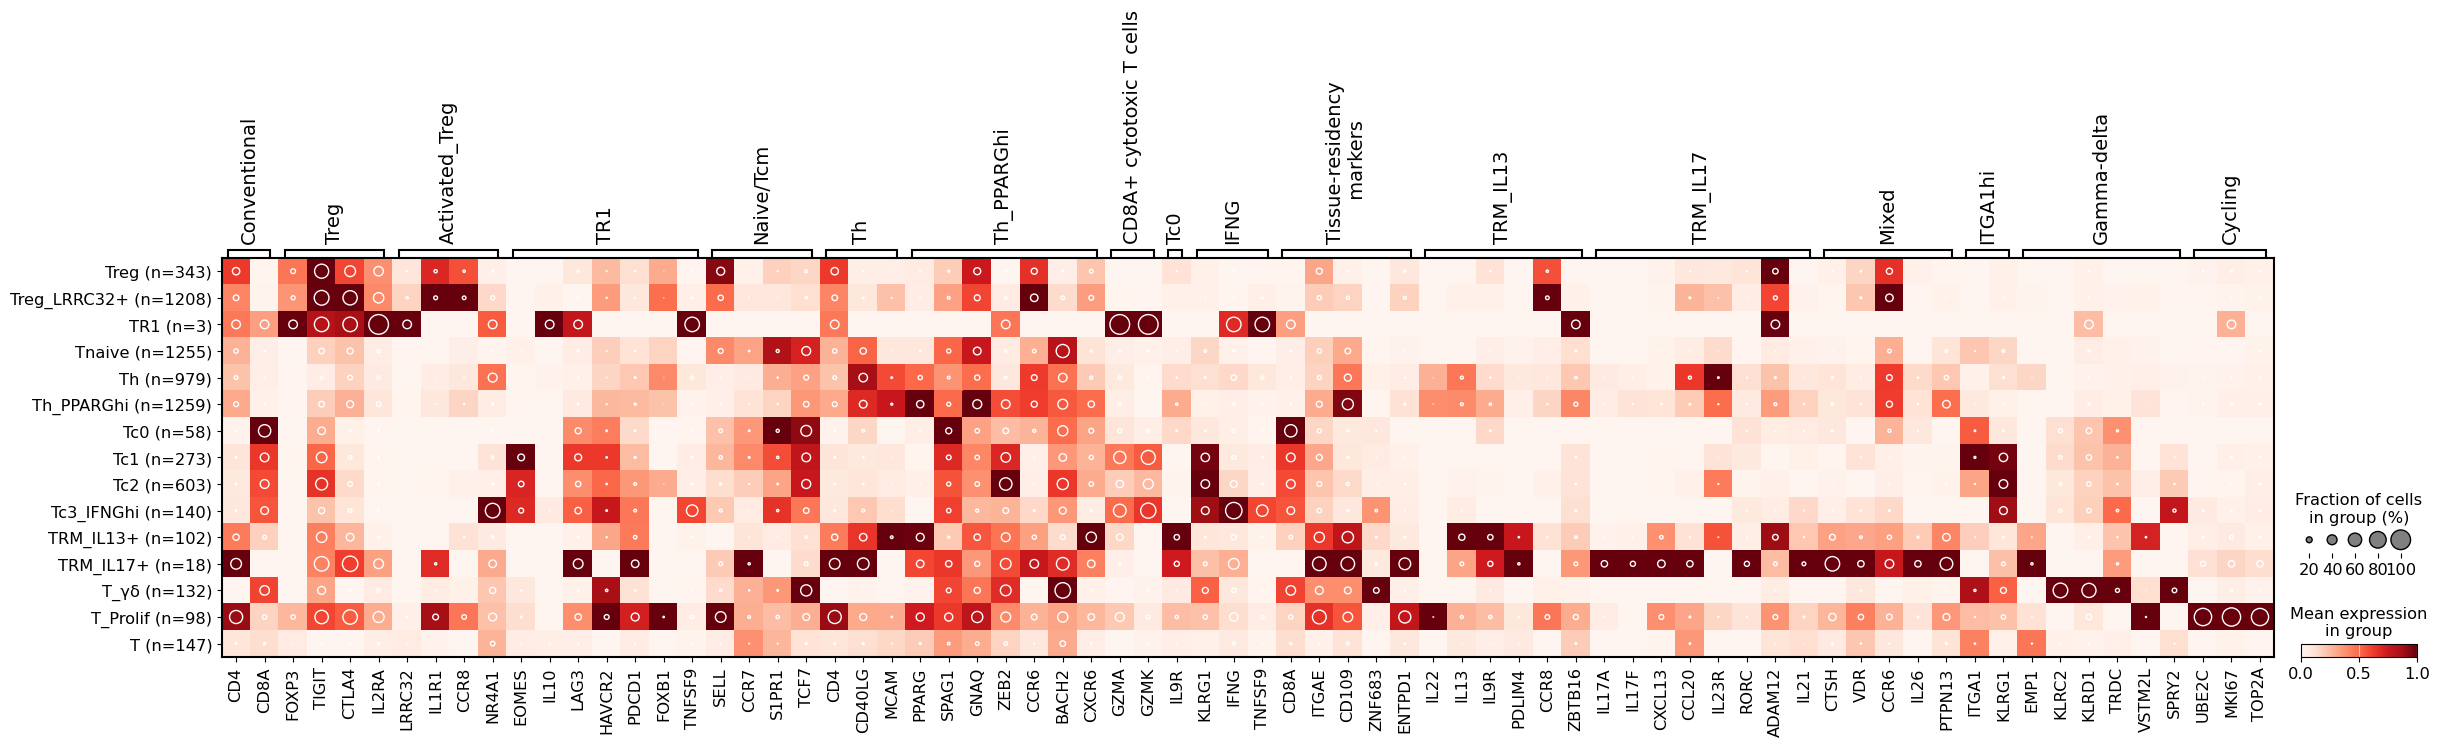

In [69]:
ALL_T={'Conventional': ['CD4', 'CD8A'],
 'Treg': ['FOXP3', 'TIGIT', 'CTLA4', 'IL2RA'],
 'Activated_Treg': ['LRRC32', 'IL1R1', 'CCR8', 'NR4A1'],
 'TR1': ['EOMES', 'IL10', 'LAG3', 'HAVCR2', 'PDCD1', 'FOXB1', 'TNFSF9'],
 'Naive/Tcm': ['SELL', 'CCR7', 'S1PR1', 'TCF7', 'PAK2', 'ICAM2'],
 'GIMAPs': ['GIMAP4', 'GIMAP5'],
 'Th': ['CD4', 'CD40LG', 'MCAM'],
 'Th_PPARGhi': ['PPARG', 'SPAG1', 'GNAQ', 'ZEB2', 'CCR6', 'BACH2', 'CXCR6'],
 'CD8A+ cytotoxic T cells': ['GZMA', 'GZMK'],
 'Tc0': ['IL9R'],
 'IFNG': ['KLRG1', 'IFNG', 'TNFSF9'],
 'Tissue-residency\n markers': ['CD8A', 'ITGAE', 'CD109', 'ZNF683', 'ENTPD1'],
 'TRM_IL13': ['IL22', 'IL13', 'IL9R', 'PDLIM4', 'CCR8', 'ZBTB16'],
 'TRM_IL17': ['IL17A',
  'IL17F',
  'CXCL13',
  'CCL20',
  'IL23R',
  'RORC',
  'ADAM12',
  'IL21'],
 'Mixed': ['CTSH', 'VDR', 'CCR6', 'IL26'],
 'Other': ['PTPN13'],
 'ITGA1hi': ['ITGA1', 'KLRG1'],
 'Gamma-delta': ['EMP1', 'KLRC2', 'KLRD1', 'TRDC', 'VSTM2L', 'SPRY2'],
 'Cycling': ['UBE2C', 'MKI67', 'TOP2A']}



# ORDER=[ 'Treg (n=443)',
#  'Treg_LRRC32+ (n=1116)',
    
#  'Tnaive (n=1321)',
#  'Th (n=2422)',
#  'Th_PPARGhi (n=2181)',
#  'Tc0 (n=292)',
#  'Tc1 (n=9)',
#  'Tc2 (n=1181)',
#  'Tc3_IFNGhi (n=417)',
#           'TRM_IL13+ (n=5)',
#  'TRM_IL17+ (n=12)',
#         'T_γδ (n=213)',
#  'T_Prolif (n=81)',

# ]


CATEGORY="provisional2"
adata_iiii = adata_mappeddata[~adata_mappeddata.obs["provisional"].str.startswith("ILC")]   
adata_iiii = adata_iiii[adata_iiii.obs["provisional"]!="NK"]   

counts = adata_iiii.obs[CATEGORY].value_counts()
valid_statuses = counts[counts >= 1].index


adata_iiii = adata_iiii[adata_iiii.obs[CATEGORY].isin(valid_statuses)].copy()
counts = adata_iiii.obs[CATEGORY].value_counts()
label_map = {group: f"{group} (n={count})" for group, count in counts.items()}
adata_iiii.obs["Patient_status_labeled"] = adata_iiii.obs[CATEGORY].map(label_map)
sorted_labels = [label_map[g] for g in counts.index]

#ORDER=['NK (n=38)', 'ILC1 (n=55)', 'ILC3 (n=48)', 'ILC_Prolif (n=5)', 'ILC2 (n=7)']

# sc.pl.DotPlot(
#     adata_iiii,  
#        ALL_T,
#     #swap_axes=True,
#     groupby="Patient_status_labeled",
#  #  vmax=.8,
    
#        categories_order=ORDER,  # <<— force your order here

 
#     #    colorbar_title='Mean expression\n(variance scaled)', 
#    standard_scale="var",
#    # categories_order=["Treg", "Treg_LRRC32+", "TR1"]
# ) \
#     .style(cmap='Reds', color_on='square', dot_edge_color='white', dot_edge_lw=1, grid=False, #vmax=.8
#                dot_max=1,   

#           )\
# .show()
ALL_T={'Conventional': ['CD4', 'CD8A'],
 'Treg': ['FOXP3', 'TIGIT', 'CTLA4', 'IL2RA'],
 'Activated_Treg': ['LRRC32', 'IL1R1', 'CCR8', 'NR4A1'],
 'TR1': ['EOMES', 'IL10', 'LAG3', 'HAVCR2', 'PDCD1', 'FOXB1', 'TNFSF9'],
 'Naive/Tcm': ['SELL', 'CCR7', 'S1PR1', 'TCF7', #'PAK2', 'ICAM2'
              ],
 #'GIMAPs': ['GIMAP4', 'GIMAP5'],
 'Th': ['CD4', 'CD40LG', 'MCAM'],
 'Th_PPARGhi': ['PPARG', 'SPAG1', 'GNAQ', 'ZEB2', 'CCR6', 'BACH2', 'CXCR6'],
 'CD8A+ cytotoxic T cells': ['GZMA', 'GZMK'],
 'Tc0': ['IL9R'],
 'IFNG': ['KLRG1', 'IFNG', 'TNFSF9'],
 'Tissue-residency\n markers': ['CD8A', 'ITGAE', 'CD109', 'ZNF683', 'ENTPD1'],
 'TRM_IL13': ['IL22', 'IL13', 'IL9R', 'PDLIM4', 'CCR8', 'ZBTB16'],
 'TRM_IL17': ['IL17A',
  'IL17F',
  'CXCL13',
  'CCL20',
  'IL23R',
  'RORC',
  'ADAM12',
  'IL21'],
 'Mixed': ['CTSH', 'VDR', 'CCR6', 'IL26', 'PTPN13'],
 'ITGA1hi': ['ITGA1', 'KLRG1'],
 'Gamma-delta': ['EMP1', 'KLRC2', 'KLRD1', 'TRDC', 'VSTM2L', 'SPRY2'],
 'Cycling': ['UBE2C', 'MKI67', 'TOP2A']}

dp = sc.pl.DotPlot(
    adata_iiii,  
       ALL_T,
    #swap_axes=True,
    groupby="Patient_status_labeled",
 #  vmax=.8,
    
       categories_order=ORDER2,  # <<— force your order here

 
    #    colorbar_title='Mean expression\n(variance scaled)', 
   standard_scale="var",
   # categories_order=["Treg", "Treg_LRRC32+", "TR1"]
)
dp = dp.style(cmap='Reds', color_on='square', dot_edge_color='white', dot_edge_lw=1, grid=False, #vmax=.8
               dot_max=1)  

          
#dp.show()   
dp.savefig("AA_Tconv_VALIDATION.pdf", dpi=300)       
    
 

In [68]:
ORDER2=[  'Treg (n=343)',
     'Treg_LRRC32+ (n=1208)',
 'TR1 (n=3)',
  'Tnaive (n=1255)',
# 'Tnaive_CD8 (n=118)',
   'Th (n=979)',

 'Th_PPARGhi (n=1259)',
  'Tc0 (n=58)',
 'Tc1 (n=273)',
 'Tc2 (n=603)',
 'Tc3_IFNGhi (n=140)',
 
 
 
 'TRM_IL13+ (n=102)',
 'TRM_IL17+ (n=18)',
  'T_γδ (n=132)',
 
 
 

 
'T_Prolif (n=98)',







 'T (n=147)',]

In [51]:
ORDER=[  'Treg (n=343)',
     'Treg_LRRC32+ (n=1208)',
 'TR1 (n=3)',
  'Tnaive (n=1255)',
# 'Tnaive_CD8 (n=118)',
   'Th (n=979)',

 'Th_PPARGhi (n=1259)',
  'Tc0 (n=58)',
 'Tc1 (n=273)',
 'Tc2 (n=603)',
 'Tc3_IFNGhi (n=140)',
 
 
 
 'TRM_IL13+ (n=102)',
 'TRM_IL17+ (n=18)',
  'T_γδ (n=132)',
 
 
 

 
  'Treg/Tnaive_prolif (n=29)',
 'Th/TRM prolif (n=49)',
 'Tc_Prolif (n=7)',
  'T_Prolif (n=13)',







 'T (n=147)',]

In [43]:
sorted(adata_iiii.obs["Patient_status_labeled"].unique())

['NK (n=28)',
 'T (n=147)',
 'TR1 (n=3)',
 'TRM_IL13+ (n=102)',
 'TRM_IL17+ (n=18)',
 'T_Prolif (n=13)',
 'T_γδ (n=132)',
 'Tc0 (n=58)',
 'Tc1 (n=273)',
 'Tc2 (n=603)',
 'Tc3_IFNGhi (n=140)',
 'Tc_Prolif (n=7)',
 'Th (n=979)',
 'Th/TRM prolif (n=49)',
 'Th_PPARGhi (n=1259)',
 'Tnaive (n=1137)',
 'Tnaive_CD8 (n=118)',
 'Treg (n=343)',
 'Treg/Tnaive_prolif (n=29)',
 'Treg_LRRC32+ (n=1208)']

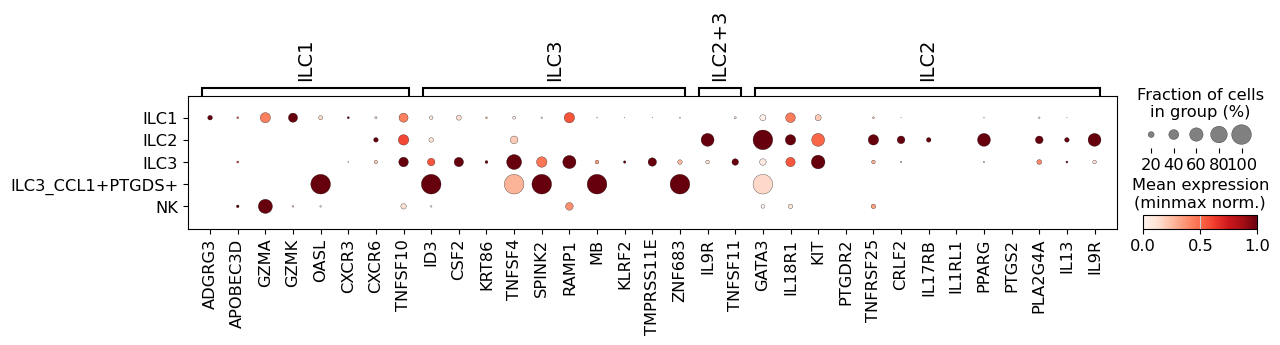

In [21]:
# """
# Merkel cells were not in the original study. Nor ILCs. So let's check if these are correct
# """
# # Exclude atlas data
# adata_mappeddata = adata[adata.obs["Mapping_status"]!="SpatialSkinAtlas"].copy()
# import gc
# gc.collect()




MARKERS = {             
 
 
    "ILC1": [ "ADGRG3", "APOBEC3D", "GZMA", 'GZMK', 'OASL',  "CXCR3", 'CXCR6' , "TNFSF10" ],
 #         "ILC1_NKp46":  ['NCR1','NCAM1','P2RX7','ZNF407','IL18','ZBTB20','CASK','ITGA1',
 # 'PLCB1','ADAM28','CNR2'],
          'ILC3': ['ID3','CSF2', 'KRT86',
 # 'ZBTB46',
  'TNFSF4',
  'SPINK2',
  'RAMP1',
  'MB',
  'KLRF2',
  'TMPRSS11E', "ZNF683"],
          

 'ILC2+3': ['IL9R', 'TNFSF11'],
       'ILC2': ['GATA3',  'IL18R1','KIT', 'PTGDR2', 'TNFRSF25',
          'CRLF2',
  'IL17RB',
  'IL1RL1',

  'PPARG',
  'PTGS2',
  'PLA2G4A',
  #'IL4',

  'IL13',
          'IL9R'],
 
        
}

adata_i= adata_mappeddata[(adata_mappeddata.obs["scanvi_predictions"]=="ILC2")|
              (adata_mappeddata.obs["scanvi_predictions"]=="ILC1")|
                           (adata_mappeddata.obs["scanvi_predictions"]=="NK")|
                      (adata_mappeddata.obs["scanvi_predictions"].str.startswith("ILC3"))
              ]

def remove_markers(LIST):
    try: 
        LIST = {key: [gene for gene in genes if gene in adata_mappeddata.var_names] 
                           for key, genes in LIST.items()}
    except: 
        LIST =[gene for gene in LIST if gene in adata_mappeddata.var_names]
    return LIST

sc.pl.dotplot(
    adata_i,
    MARKERS,
    groupby="scanvi_predictions",
    standard_scale="var",
    dendrogram=False,
    vmax=1,
                               colorbar_title="Mean expression\n(minmax norm.)",
    #categories_order = ["Merkel cell", "ILC1", "ILC3", "ILC2"],
                                  #  save="misc_scrna.pdf"

) 


In [ ]:
# sc.pp.neighbors(adata_i, use_rep = 'X_scanvi', metric = "euclidean", 
#                 n_neighbors=20,key_added="neighbor_20")

# print("neighbours done")
# print("start umap")
# sc.tl.umap(adata_i, min_dist=0.1, neighbors_key = "neighbor_20" ) 

# sc.pl.umap(
#     adata_i,
#     color=[
#       'scanvi_predictions',
#     ],
#     legend_loc="on data",
#     s=100, 
#     legend_fontoutline=2,
#     legend_fontsize=20,
#     show=True,
#     palette=colors
# )
# #sc.tl.leiden(adata_i, resolution=1, key_added='leiden_res1', neighbors_key="neighbor_20")


ERROR: Please check that the categories given by the `order` parameter match the categories that want to be reordered.

Mismatch: set()

Given order categories: ['Merkel cell', 'ILC1', 'ILC3', 'ILC2']

scanvi_predictions categories: ['ILC1', 'ILC2', 'ILC3']



AttributeError: 'DotPlot' object has no attribute 'group_extra_size'

In [ ]:
"""
So even with the scanvi predictions, we can resolve rare cell types not originally captured!
"""

In [ ]:
"""
I thought it would be interesting to check some of the other populations, like F4: DP_HHIP+, ASIC2+, TransitionalDC, 
Mac_CX3CR1+, 
+ eosinophils! 
"""
MARKERS = {     "Mechanoreceptor": ["ASIC2","CA10", "DCC", "CDH4", "CDH18","GRM8",
                        "LRP1B", #"IL1RAPL1","CTNNA2", "SUGCT", "NRXN1", "OPCML", 
               "RBFOX1", #"DOK6", 
               "HYDIN", #"RYR3",
               "RALYL", "GRM7", "NDST3",  'CSMD1','LHFPL3',
'IQGAP2', 'CD96', 'DNAH14', 'IGF2BP3', 'CPEB3', 'TBXAS1', 'PHEX', 'ABCB1', 'DPYD',                        
               #"HULC", "RYR3", "DMD", "ROBO2", "TENM2", "NRG3", "PCAT1", "CACNA2D3", 
               #"DLC1", "NAV3"
              
                       ],
            "Eosinophils": [ "CLC", "CCR3",#"CCL23",    #"PTGDR2", "P2RY1", 
                            "S100P",
                             "IL4",
    "IL13",
    "ETS1",
    "KLF5",
    "NTRK1",
    "KCNJ2",
    "IPO11",
    "CYP11A1",
    "TNFSF11",
    "OSM"
                           ], 
    
    'F4: DP_HHIP+': ['CORIN',
  'BMP7',
  'WNT5A',
  'LEF1',
  'HHIP',
  'RSPO3',
  #'INHBA',
  'PTCH1', "ALPL", "CACNA1D", "ALPL", "TFAP2C","FGFR3", "SH2B2","LAMA3",
],   
           'CX3CR1+MAC': ['TREM2', 'SPP1',  "LPL", 'CX3CR1', #'ADRB1', 
              # "KCNQ3"#"UNC5B", "GPR34", "SMAD7",  "CD72", "TGFBR1", 
             #  "CD9",
               
                "P2RY12", #'ADAMDEC1',
                'FCGR3A', 
                'TGFBR1', 'PRKCH', 'CD93', 'HTRA1', "ADRB1",
                'GDF11', 'OLR1', 'ITGB3'
               ],
             'AXL+SIGLEC6+': ['AXL', 'SIGLEC6', 'NUMBL', 'IFI27', 'CXCR3', 'PLXNA4', 'KDR', "SELL",
                             "TNFSF4", "TCF4"],    

        }
        
adata_i= adata[(adata.obs["scanvi_predictions"]=="Eosinophil")|
              (adata.obs["scanvi_predictions"]=="F4: DP_HHIP+")|
                      (adata.obs["scanvi_predictions"].str.startswith("ASIC2"))|
                                     (adata.obs["scanvi_predictions"].str.startswith("Mac_CX"))|

                  (adata.obs["scanvi_predictions"]=="TransitionalDC")
               
              ]
 



sc.pl.dotplot(
    adata_i,
    MARKERS,
    groupby="scanvi_predictions",
    standard_scale="var",
    dendrogram=False,
    vmax=1,
                               colorbar_title="Mean expression\n(minmax norm.)",
    #categories_order = ["Merkel cell", "ILC1", "ILC3", "ILC2"],
                                  #  save="misc_scrna.pdf"

) 



# Next steps would be clustering data 

In [ ]:
"""
In the examples in the paper, we processed specific clusters separately while retaining the atlas data (we would recommend this approach for xenium data in particular),
and then confirmed the populations were appropriately annotated later (see marker genes from supp figure 2-11 in paper)
"""

# Save scanvi_predictions to evaluate low-resource mapping (not necessary for tutorial)

In [ ]:
stop

In [ ]:
import scanpy as sc
adata=sc.read_h5ad('/lustre/scratch124/cellgen/haniffa/projects/adult_skin_v1/nobackup_output//SpatialSkinAtlasMapping_scanviSpatialSkinAtlasMapping_TUTORIAL_HVGNUMBER5704__MAXEPOCHS10__BATCHKEYsample_id/adata_all_TUTORIAL+HVGNUMBER5704__MAXEPOCHS10__BATCHKEYsample_id.h5ad')

In [ ]:
adata = adata[adata.obs["Mapping_status"]!="SpatialSkinAtlas"].copy()
import gc
gc.collect()

In [ ]:
scanvi_predictions_dict = adata.obs["scanvi_predictions"].to_dict()

import pickle
scanvi_predictions_dict = adata.obs["scanvi_predictions"].to_dict()

outpath = "/nfs/team298/ls34/dicts/tutorial_scanvi_predictions.pkl"


with open(outpath, "wb") as f:
    pickle.dump(scanvi_predictions_dict, f)

print("Saved to:", outpath)

# Versions

In [ ]:
sc.logging.print_versions()


